In [186]:
from pgmpy.models import BayesianNetwork
from pgmpy.estimators import MaximumLikelihoodEstimator, BayesianEstimator, ParameterEstimator
from pgmpy.inference import VariableElimination
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference.CausalInference import CausalInference

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import daft
from daft import PGM

import sys
import psutil
import os

In [187]:
covid = pd.read_excel("symptomatic_dataset.xlsx")
covid.head(2)

,ID,Completion_Date,Age,Gender,Banana,Caramel,Mint,Orange,Pineapple,Vanilla,1__Rinitis_or_Sinusitis,2__Respiratory_allergies,3__Hypertension,4__Diabetes,5__Parkinson,6__Alzheimer,7__Cold,8__Cough,9__Fever,10__Muscular_pain,11__Breathing_difficulty,12__Other_COMMENTS,13__Days_with_symptoms,Smoker,COVI19_PCR
0,1,2020-06-01,30,Female,0,0,1,0,1,1,0,0,0,0,0,0,1,0,0,0,0,anosmia,3,0,1
1,2,2020-06-01,31,Female,0,1,1,1,0,1,0,0,0,0,0,0,0,1,0,1,0,NaN,2,0,1


In [188]:

#Create a mask based on the condition
mask = (covid['Banana'] + covid['Caramel'] + covid['Mint'] + covid['Orange'] + covid['Pineapple'] + covid['Vanilla']) > 3

#Assign the values 1 or 0 to the new column based on the mask
covid['Anosmia'] = mask.astype(int)



In [189]:
#drop columns that are not predictors
dropthis = ["ID", "Completion_Date", #"12__Other_COMMENTS",
            "Banana", "Caramel", "Mint", "Orange", "Pineapple", "Vanilla"]
covid = covid.drop(dropthis, axis=1)

In [190]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.expand_frame_repr', False)

In [191]:
# Create a DataFrame with binary encoding for the presence of each value
binary_comments = covid['12__Other_COMMENTS'].str.get_dummies(sep=',')

In [192]:
#deleting spaces before column names
binary_comments.columns = [col.lstrip() for col in binary_comments.columns]
#checking stats
#binary_comments.sum().sort_values(ascending=False)

In [193]:
binary_comments = binary_comments.sort_index(axis=1)
binary_comments.head(2)

,ageusia,ageusia,allergy,angina,anosmia,anosmia,asma,augesia,bronchitis,chest pain,chest pain,chest pain,clogged nose,cough,depression,depression,dermomiositis,diarrhea,diarrhea,diarrhea anosmia,dizziness,dizziness,dysphagia,dyspnea,dyspnea,ear pain,fatigue,fatigue,fever,fever,fibromyalgia,headache,headache,headache Y diarrhea,headache.,headaches,hiposmia,hipotiridismo,hypothyroidism,indigestion,indigestion,lack of appetite,lack of appetite,lupus,nausea,nausea,nauseas,neumonia,odynophagia,odynophagia,otalgia,pharyngeal itching,rhinorrea,rhinorrhea,shivers,sore throat,sore throat,stomach pain,stomach pain,sweating,vomiting,vomiting nausea
0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [194]:
headache_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'headache' in col_name]
binary_comments['Headache'] = binary_comments.iloc[:, headache_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[headache_cols], axis=1, inplace=True)

In [195]:
headache_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'headache' in col_name]
binary_comments['Headache'].sum()

137

In [196]:
anosmia_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'anosmia' in col_name]
binary_comments['Anosmia'] = binary_comments.iloc[:, anosmia_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[anosmia_cols], axis=1, inplace=True)

In [197]:
binary_comments['Anosmia'].sum()

58

In [198]:
ageusia_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'ageusia' in col_name]
binary_comments['Ageusia'] = binary_comments.iloc[:, ageusia_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[ageusia_cols], axis=1, inplace=True)

#augesia                  3
augesia_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'augesia' in col_name]
binary_comments['Augesia'] = binary_comments.iloc[:, augesia_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[augesia_cols], axis=1, inplace=True)

binary_comments['Ageusia'] = (binary_comments['Ageusia'] + binary_comments['Augesia']).clip(upper=1)

# And then, drop the misspelled column:
binary_comments.drop('Augesia', axis=1, inplace=True)

In [199]:
odynophagia_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'odynophagia' in col_name]
binary_comments['Odynophagia'] = binary_comments.iloc[:, odynophagia_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[odynophagia_cols], axis=1, inplace=True)

In [200]:
#diarrhea                13
diarrhea_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'diarrhea' in col_name]
binary_comments['Diarrhea'] = binary_comments.iloc[:, diarrhea_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[diarrhea_cols], axis=1, inplace=True)

In [201]:
#asma
asthma_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'asma' in col_name]
binary_comments['Asthma'] = binary_comments.iloc[:, asthma_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[asthma_cols], axis=1, inplace=True)

In [202]:
#hypothyroidism
hypothyroidism_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'hypothyroidism' in col_name]
binary_comments['Hypothyroidism'] = binary_comments.iloc[:, hypothyroidism_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[hypothyroidism_cols], axis=1, inplace=True)

In [203]:
#diarrhea
diarrhea_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'diarrhea' in col_name]
binary_comments['Diarrhea'] = binary_comments.iloc[:, diarrhea_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[diarrhea_cols], axis=1, inplace=True)

In [204]:
#sore throat
sore_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'sore throat' in col_name]
binary_comments['SoreThroat'] = binary_comments.iloc[:, sore_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[sore_cols], axis=1, inplace=True)

In [205]:
#fatigue                  4
fatigue_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'fatigue' in col_name]
binary_comments['Fatigue'] = binary_comments.iloc[:, fatigue_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[fatigue_cols], axis=1, inplace=True)

In [206]:
#stomach pain             3
stomach_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'stomach pain' in col_name]
binary_comments['Stomach'] = binary_comments.iloc[:, stomach_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[stomach_cols], axis=1, inplace=True)

In [207]:
#clogged nose             3
clogged_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'clogged nose' in col_name]
binary_comments['CloggedNose'] = binary_comments.iloc[:, clogged_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[clogged_cols], axis=1, inplace=True)

In [208]:
#fever                    2
fever_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'fever' in col_name]
binary_comments['Fever'] = binary_comments.iloc[:, fever_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[fever_cols], axis=1, inplace=True)

In [209]:
#chest pain                    2
chest_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'chest pain' in col_name]
binary_comments['ChestPain'] = binary_comments.iloc[:, chest_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[chest_cols], axis=1, inplace=True)

In [210]:
#dizziness                   2
dizziness_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'dizziness' in col_name]
binary_comments['Dizziness'] = binary_comments.iloc[:, dizziness_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[dizziness_cols], axis=1, inplace=True)

In [211]:
1
#shivers                   2
shivers_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'shivers' in col_name]
binary_comments['Shivers'] = binary_comments.iloc[:, shivers_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[shivers_cols], axis=1, inplace=True)

In [212]:
#lack of appetite                    2
noAppetite_cols = [i for i, col_name in enumerate(binary_comments.columns) if 'lack of appetite' in col_name]
binary_comments['LossAppetite'] = binary_comments.iloc[:, noAppetite_cols].any(axis=1).astype(int)

# Delete the columns compared
binary_comments.drop(binary_comments.columns[noAppetite_cols], axis=1, inplace=True)

In [213]:
sums = binary_comments.sum()
#Filter columns where the sum is greater than 1
columns_to_keep = sums[sums > 1].index
#Keep only those columns
binary_comments = binary_comments[columns_to_keep]
binary_comments.head()

,Headache,Anosmia,Ageusia,Odynophagia,Asthma,Hypothyroidism,SoreThroat,Fatigue,Stomach,CloggedNose,Fever,ChestPain,Dizziness,Shivers,LossAppetite
0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [214]:
#Age ranges
age_groups = {
    range(0, 13): 0, #'0-12',
    range(13, 25): 1, #'13-24',
    range(25, 45): 2, #'25-44',
    range(45, 66): 3, #'45-65',
    range(66, 120): 4, #'66+'
}

gender = {'Female': 0, 'Masculine': 1} 

# encode the age and gender
covid['Age_group'] = covid['Age'].map(lambda Age: next((a for b, a in age_groups.items() if Age in b), None))
covid['Gender'] = covid['Gender'].map(gender)

In [215]:
covid.columns

Index(['Age', 'Gender', '1__Rinitis_or_Sinusitis', '2__Respiratory_allergies',
       '3__Hypertension', '4__Diabetes', '5__Parkinson', '6__Alzheimer',
       '7__Cold', '8__Cough', '9__Fever', '10__Muscular_pain',
       '11__Breathing_difficulty', '12__Other_COMMENTS',
       '13__Days_with_symptoms', 'Smoker', 'COVI19_PCR', 'Anosmia',
       'Age_group'],
      dtype='object')

#drop Age: age group, Parkinson and Alzheimer has no variance
dropthis = ["Age","Parkinson", "Alzheimer","12__Other_COMMENTS"]
covid= covid.drop(dropthis, axis=1)

In [216]:
covid = pd.merge(covid, binary_comments, how='outer', left_index=True, right_index=True, suffixes=('_initial', '_comment'))

In [217]:
covid.head(3)

,Age,Gender,1__Rinitis_or_Sinusitis,2__Respiratory_allergies,3__Hypertension,4__Diabetes,5__Parkinson,6__Alzheimer,7__Cold,8__Cough,9__Fever,10__Muscular_pain,11__Breathing_difficulty,12__Other_COMMENTS,13__Days_with_symptoms,Smoker,COVI19_PCR,Anosmia_initial,Age_group,Headache,Anosmia_comment,Ageusia,Odynophagia,Asthma,Hypothyroidism,SoreThroat,Fatigue,Stomach,CloggedNose,Fever,ChestPain,Dizziness,Shivers,LossAppetite
0,30,0,0,0,0,0,0,0,1,0,0,0,0,anosmia,3,0,1,0,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,31,0,0,0,0,0,0,0,0,1,0,1,0,NaN,2,0,1,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,30,0,1,0,0,0,0,0,1,0,0,1,0,NaN,3,0,1,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [218]:
#combining similar columns
covid['9__Fever'] = covid['9__Fever'] + covid['Fever']
covid = covid.drop(['Fever'], axis=1)

pd.Categorical(covid['Gender']).describe()
covid['Gender'] = covid['Gender'].map({'Masculine': 0, 'Female': 1})

In [219]:
covid.columns

Index(['Age', 'Gender', '1__Rinitis_or_Sinusitis', '2__Respiratory_allergies',
       '3__Hypertension', '4__Diabetes', '5__Parkinson', '6__Alzheimer',
       '7__Cold', '8__Cough', '9__Fever', '10__Muscular_pain',
       '11__Breathing_difficulty', '12__Other_COMMENTS',
       '13__Days_with_symptoms', 'Smoker', 'COVI19_PCR', 'Anosmia_initial',
       'Age_group', 'Headache', 'Anosmia_comment', 'Ageusia', 'Odynophagia',
       'Asthma', 'Hypothyroidism', 'SoreThroat', 'Fatigue', 'Stomach',
       'CloggedNose', 'ChestPain', 'Dizziness', 'Shivers', 'LossAppetite'],
      dtype='object')

In [220]:
covid = covid.rename(columns={'1__Rinitis_or_Sinusitis': 'RinitisSinusitis',
                        '2__Respiratory_allergies': 'RespiratoryAllegies',
                        '3__Hypertension': 'Hypertension',
                        '4__Diabetes': 'Diabetes',
                        '5__Parkinson': 'Parkinson',
                        '6__Alzheimer': 'Alzheimer',
                        '7__Cold': 'Cold',
                        '8__Cough': 'Cough',
                        '9__Fever': 'Fever',
                        '10__Muscular_pain': 'MuscularPain',
                        '11__Breathing_difficulty': 'BreatheDiff',
                        '13__Days_with_symptoms': 'SymptomDays'                       
                       })

sums = covid.sum()
columns_to_keep = sums[sums > 1].index
covid = covid[columns_to_keep]

In [221]:
covid.columns

Index(['Age', 'Gender', 'RinitisSinusitis', 'RespiratoryAllegies',
       'Hypertension', 'Diabetes', 'Parkinson', 'Alzheimer', 'Cold', 'Cough',
       'Fever', 'MuscularPain', 'BreatheDiff', '12__Other_COMMENTS',
       'SymptomDays', 'Smoker', 'COVI19_PCR', 'Anosmia_initial', 'Age_group',
       'Headache', 'Anosmia_comment', 'Ageusia', 'Odynophagia', 'Asthma',
       'Hypothyroidism', 'SoreThroat', 'Fatigue', 'Stomach', 'CloggedNose',
       'ChestPain', 'Dizziness', 'Shivers', 'LossAppetite'],
      dtype='object')

In [222]:
dropthis = ["Age", "Parkinson", "Alzheimer","12__Other_COMMENTS"]
covid= covid.drop(dropthis, axis=1)
covid.head()       

,Gender,RinitisSinusitis,RespiratoryAllegies,Hypertension,Diabetes,Cold,Cough,Fever,MuscularPain,BreatheDiff,SymptomDays,Smoker,COVI19_PCR,Anosmia_initial,Age_group,Headache,Anosmia_comment,Ageusia,Odynophagia,Asthma,Hypothyroidism,SoreThroat,Fatigue,Stomach,CloggedNose,ChestPain,Dizziness,Shivers,LossAppetite
0,0,0,0,0,0,1,0,0,0,0,3,0,1,0,2,0,1,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,1,0,2,0,1,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,0,1,0,0,0,1,0,0,1,0,3,0,1,1,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,1,1,1,1,0,2,0,1,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,1,0,0,0,0,1,1,1,0,0,2,0,1,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0


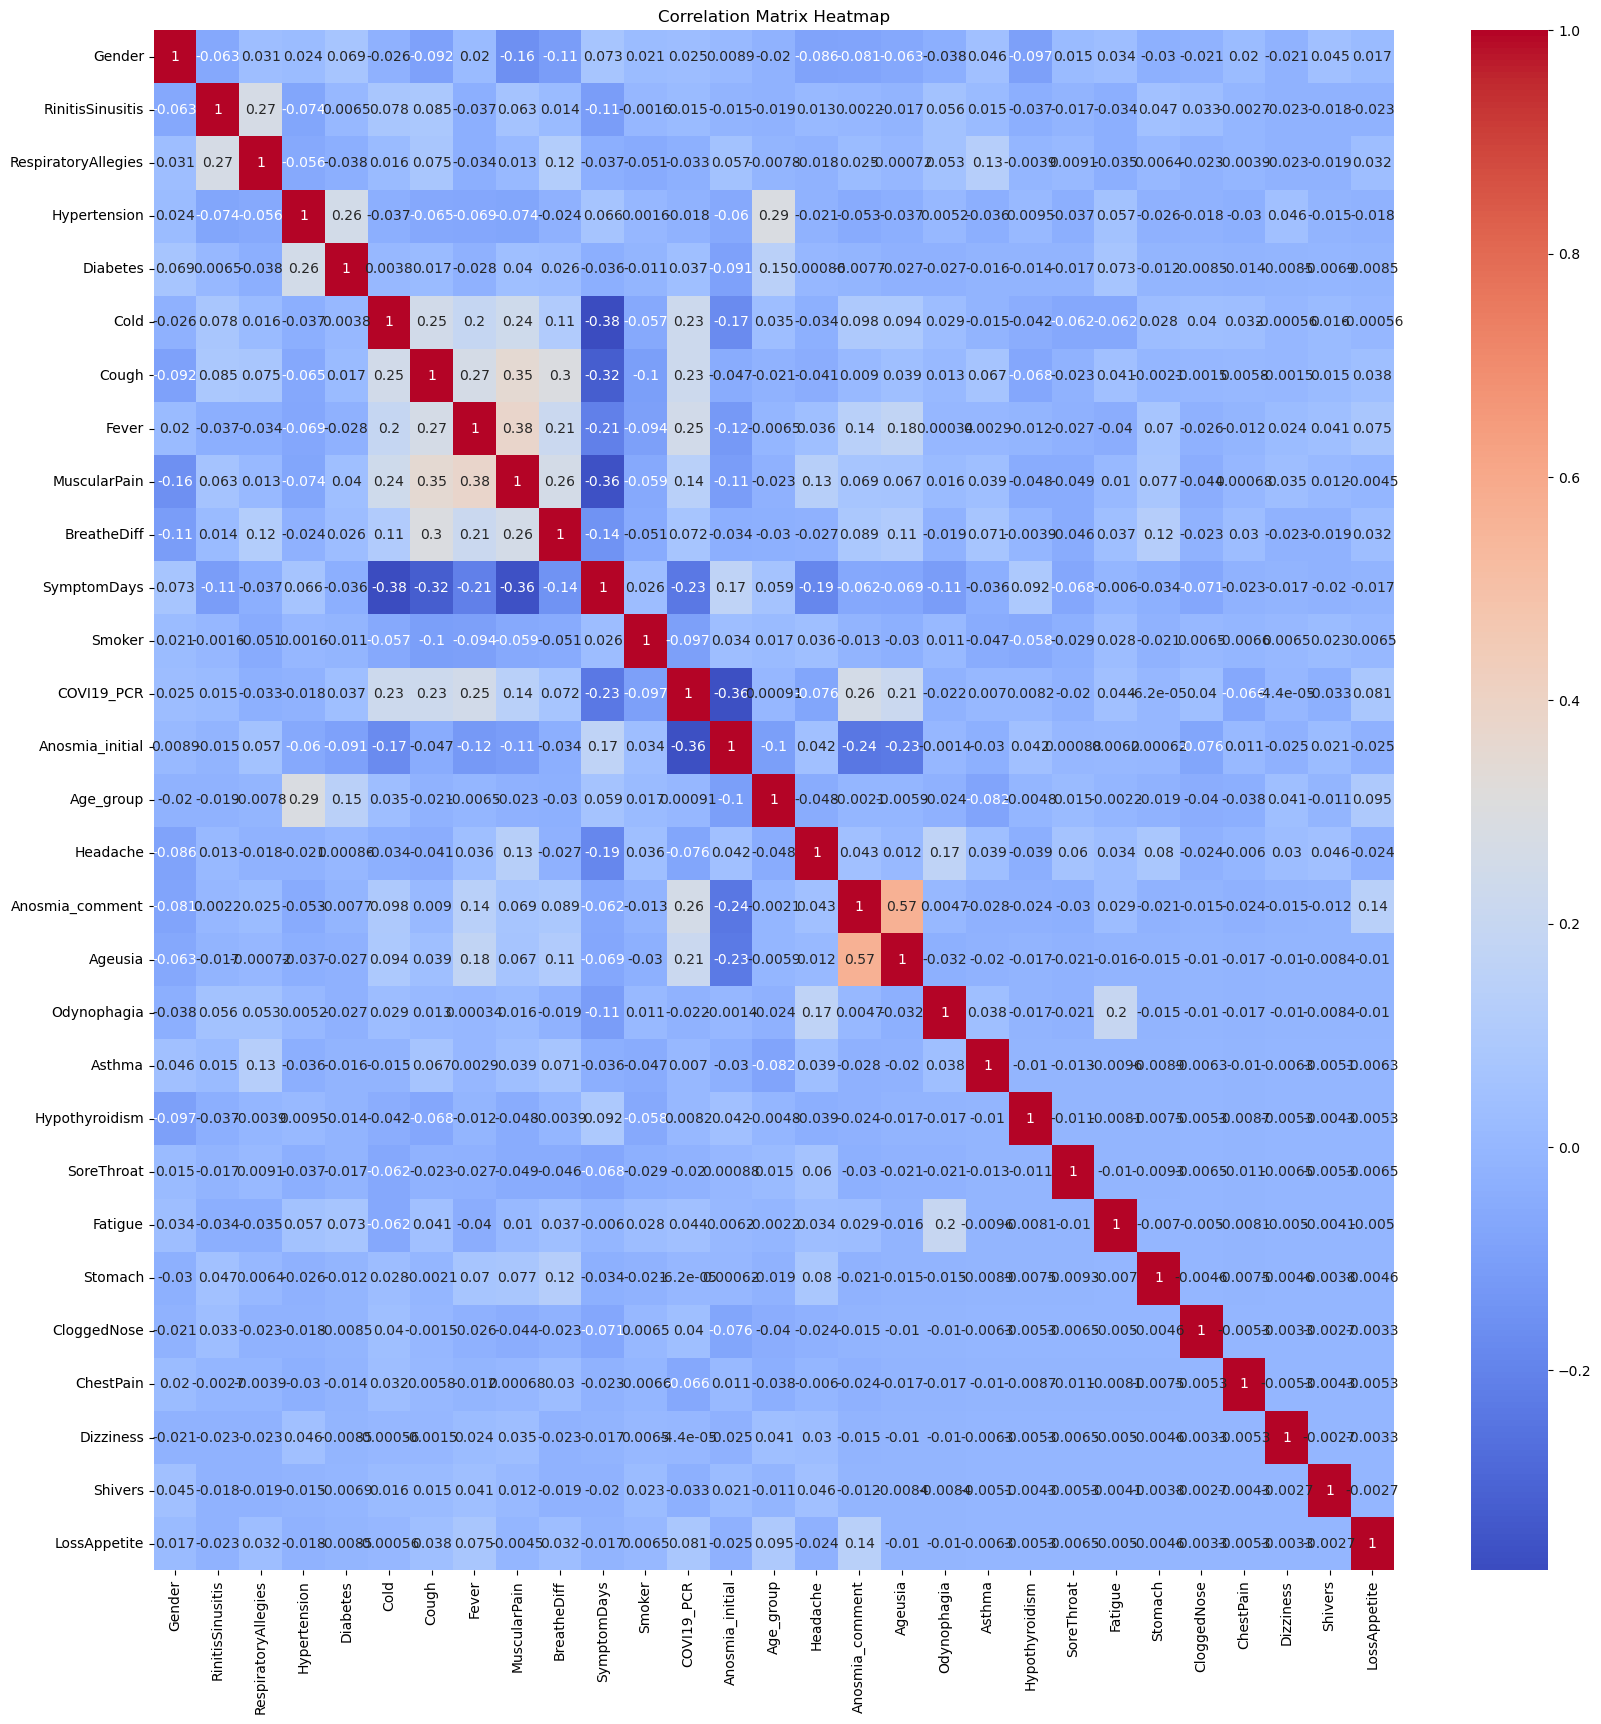

In [223]:
import seaborn as sns
import numpy as np
correlation_matrix = np.corrcoef(covid, rowvar=False)

# Create a heatmap using seaborn
plt.figure(figsize=(20, 20))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',xticklabels=covid.columns,
            yticklabels=covid.columns)
plt.title("Correlation Matrix Heatmap")
plt.show()

In [224]:
target = "COVI19_PCR"
# Define features as all columns except the target variable
features = covid.drop(columns=[target]).columns.tolist()
features



['Gender',
 'RinitisSinusitis',
 'RespiratoryAllegies',
 'Hypertension',
 'Diabetes',
 'Cold',
 'Cough',
 'Fever',
 'MuscularPain',
 'BreatheDiff',
 'SymptomDays',
 'Smoker',
 'Anosmia_initial',
 'Age_group',
 'Headache',
 'Anosmia_comment',
 'Ageusia',
 'Odynophagia',
 'Asthma',
 'Hypothyroidism',
 'SoreThroat',
 'Fatigue',
 'Stomach',
 'CloggedNose',
 'ChestPain',
 'Dizziness',
 'Shivers',
 'LossAppetite']

1/1 [==============================] - 0s 11ms/step


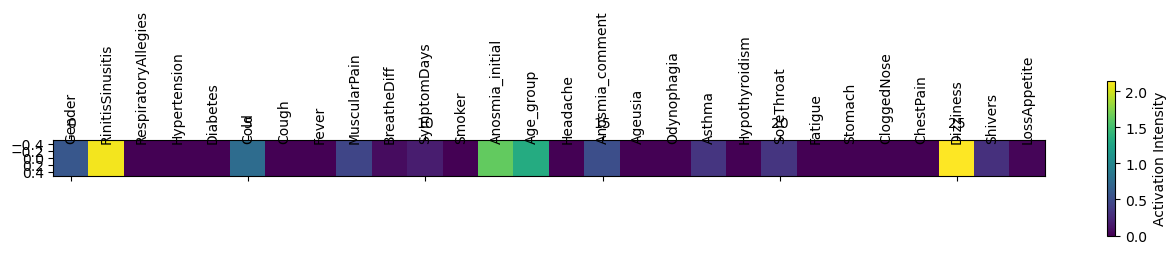

6/6 [==============================] - 0s 390us/step


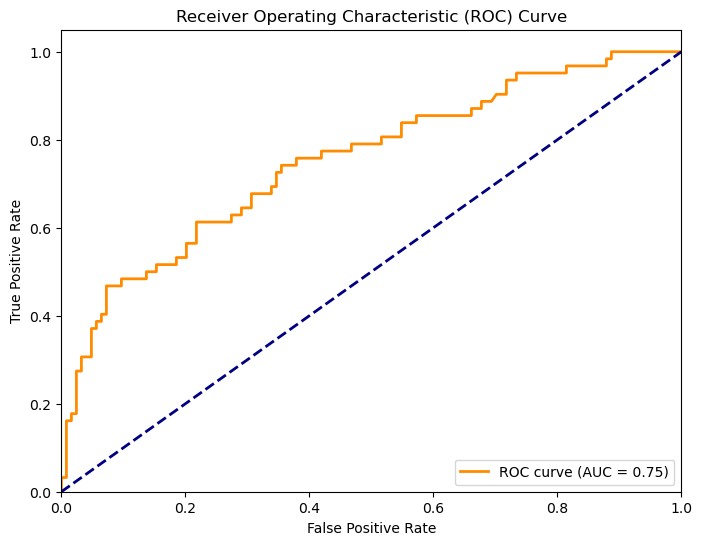

1/1 [==============================] - 0s 12ms/step


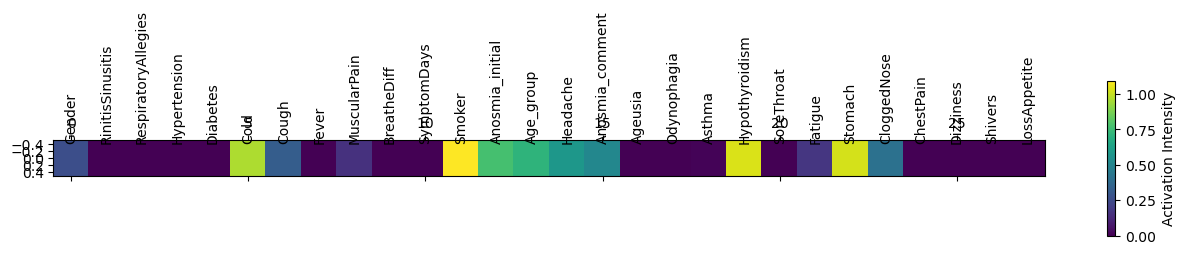

6/6 [==============================] - 0s 419us/step


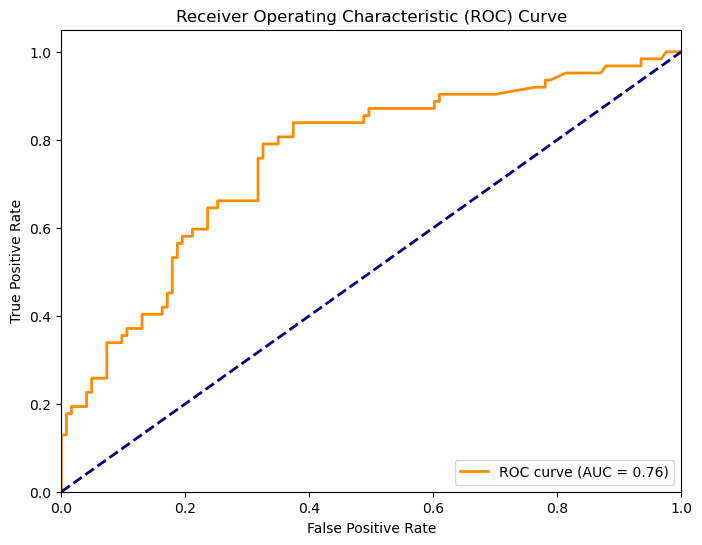

1/1 [==============================] - 0s 13ms/step


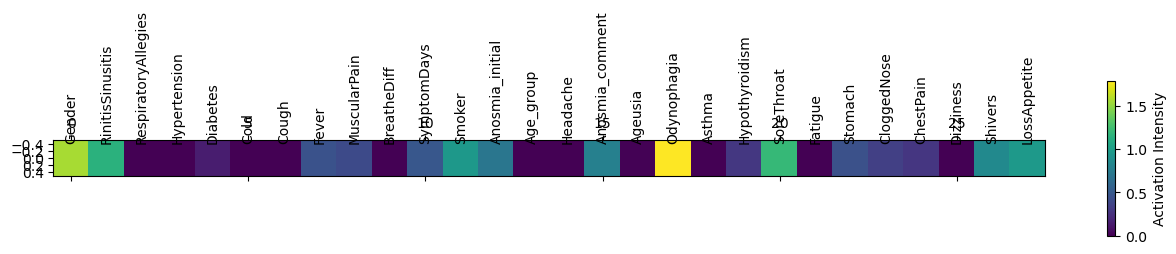

6/6 [==============================] - 0s 406us/step


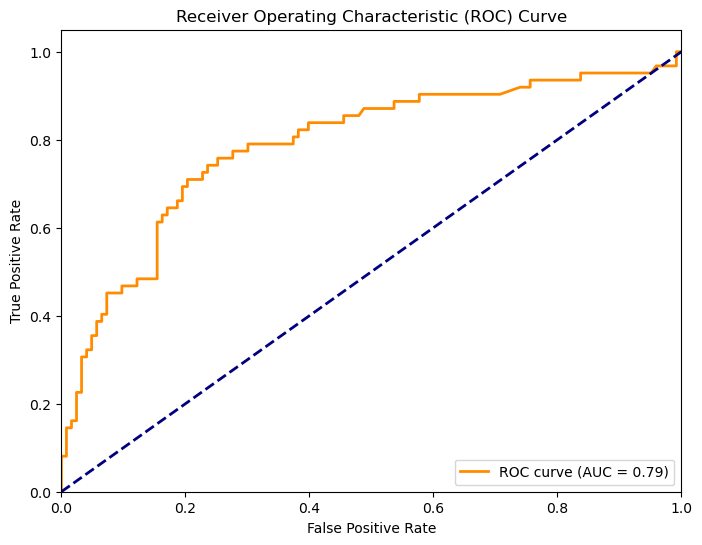

1/1 [==============================] - 0s 11ms/step


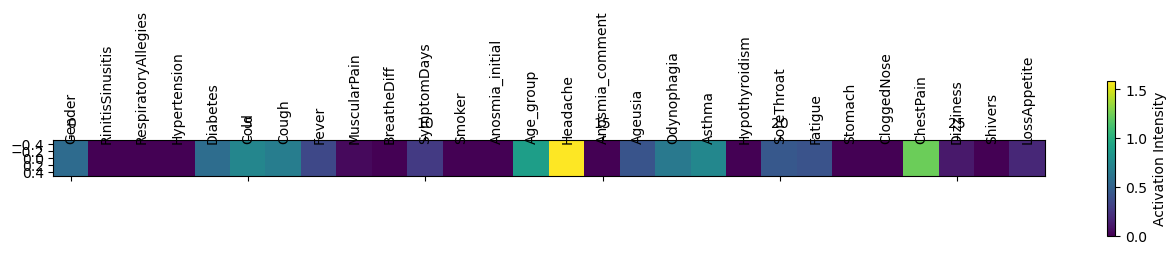

6/6 [==============================] - 0s 399us/step


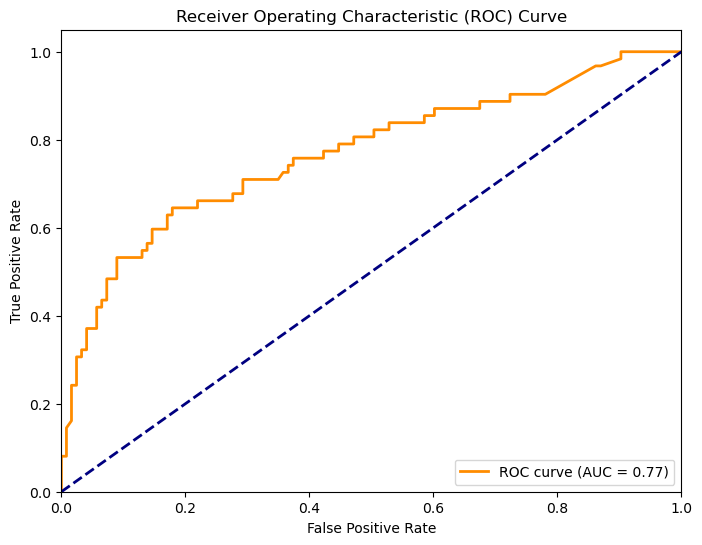

1/1 [==============================] - 0s 12ms/step


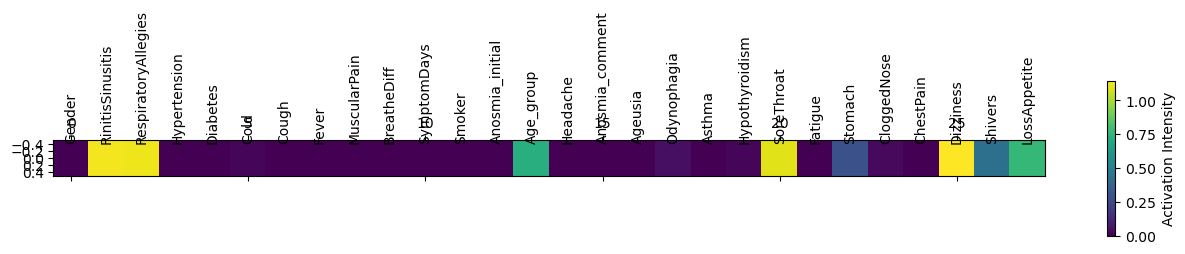

6/6 [==============================] - 0s 394us/step


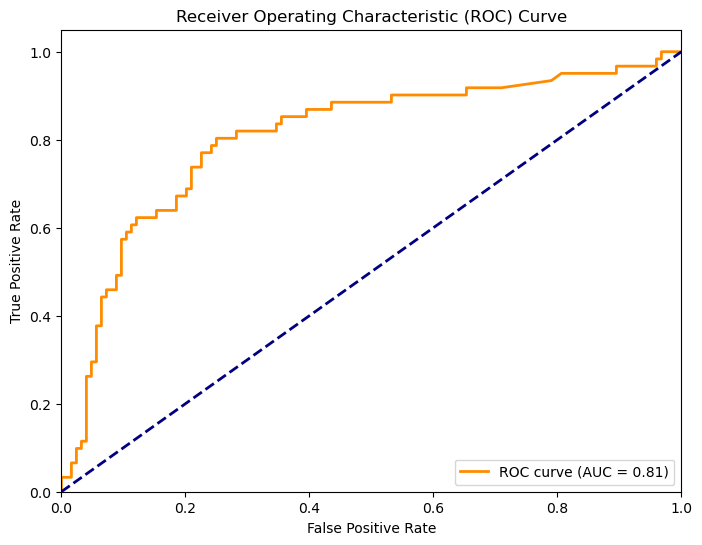

Average ROC AUC: 0.7739910158031826


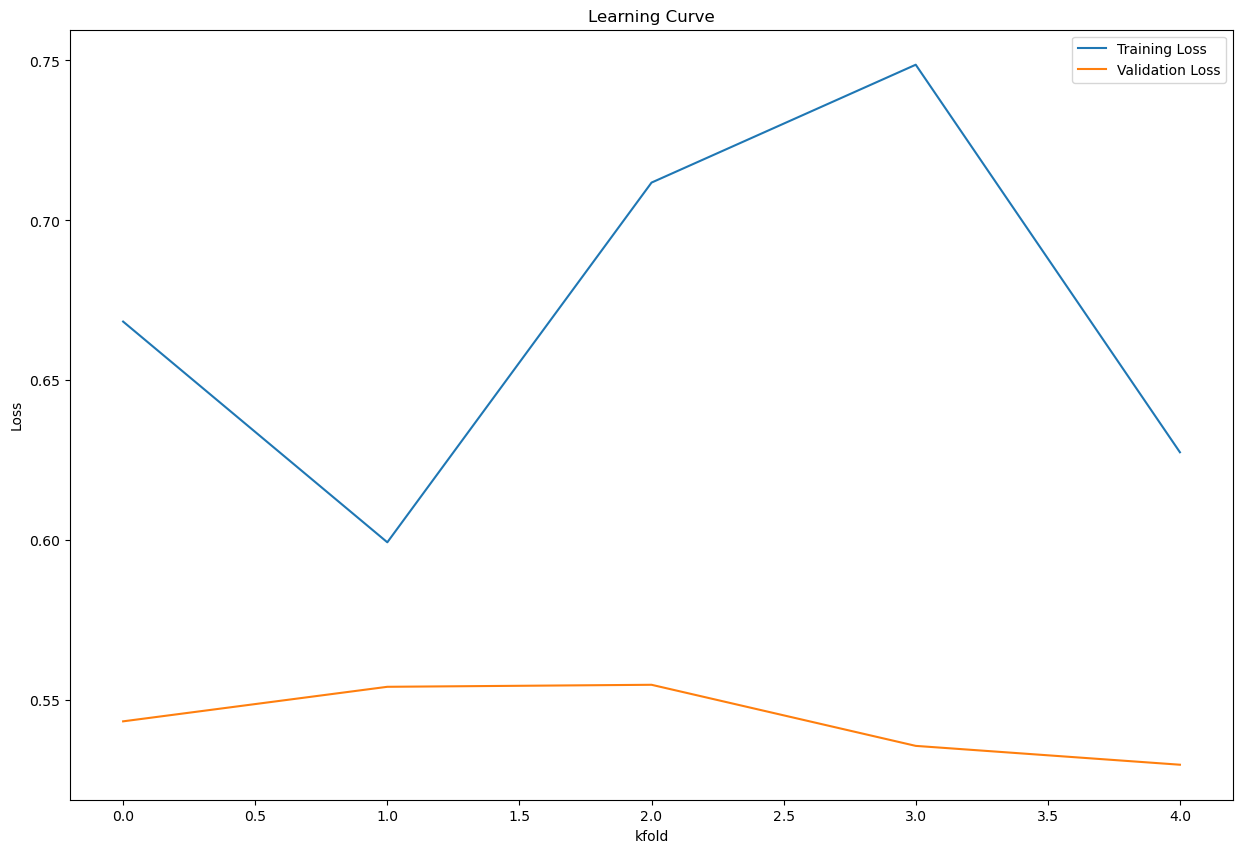

In [225]:
from sklearn.model_selection import KFold
from sklearn.model_selection import KFold
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt

#defining features and target

roc_auc_scores = []
tpr_list = [] 
fpr_list = [] 
X = covid[features]
y = covid[target]
# K-Fold Cross-Validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
accuracies = []
train_losses=[]
val_losses=[]
for train_idx, val_idx in kfold.split(X,y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(28, activation='relu', input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(9, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    history=model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
    train_losses.append(history.history['loss'][0])
    
    accuracy = model.evaluate(X_val, y_val)[1]
    
    val_losses.append(model.evaluate(X_val, y_val)[0])
    accuracies.append(accuracy)
    
    
    layer_to_visualize = model.layers[0]
    
    # Create a model to output the activations of the chosen layer
    activation_model = tf.keras.Model(inputs=model.input, outputs=layer_to_visualize.output)
    
    # Get activations for a sample data point (X_val[0] or any other sample)
    sample_activations = activation_model.predict(np.expand_dims(X_val.iloc[0], axis=0))
    # Assuming sample_activations is of shape (width,)
    sample_activations_reshaped = sample_activations.reshape(1, -1)  # Reshape to (1, width)
    plt.matshow(sample_activations_reshaped, cmap='viridis')
    plt.colorbar(label='Activation Intensity')

    feature_names = features
    for i in range(len(feature_names)):
        plt.annotate(feature_names[i], (i, -0.5), rotation='vertical', ha='center')
    plt.show()
    
    
    
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
    y_pred_prob = model.predict(X_val)
    
    # Compute ROC curve and AUC for the current fold
    fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    roc_auc_scores.append(roc_auc)
    
    tpr_list.append(tpr)
    fpr_list.append(fpr)
    # Plot the average ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()
    
    
    
    
    
    
    
    


average_accuracy = np.mean(accuracies)
#print(f'Average Cross-Validation Accuracy: {average_accuracy:.2f}')train_losses.append(history.history['loss'][0]) 
average_roc_auc = sum(roc_auc_scores) / len(roc_auc_scores)
print("Average ROC AUC:", average_roc_auc)
plt.figure(figsize=(15, 10))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Learning Curve')
plt.xlabel('kfold')
plt.ylabel('Loss')
plt.legend()
plt.show()






1/1 [==============================] - 0s 12ms/step


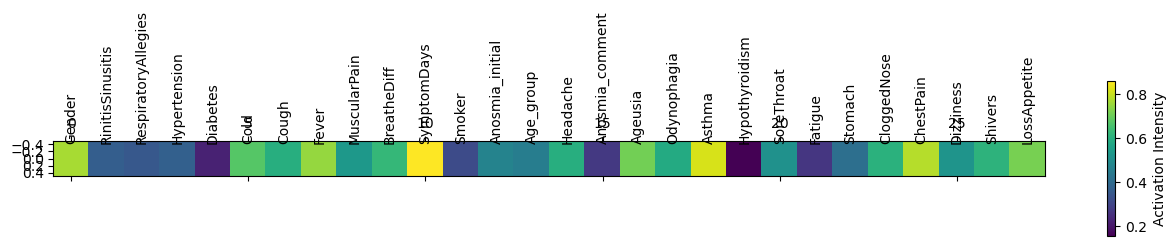

6/6 [==============================] - 0s 436us/step


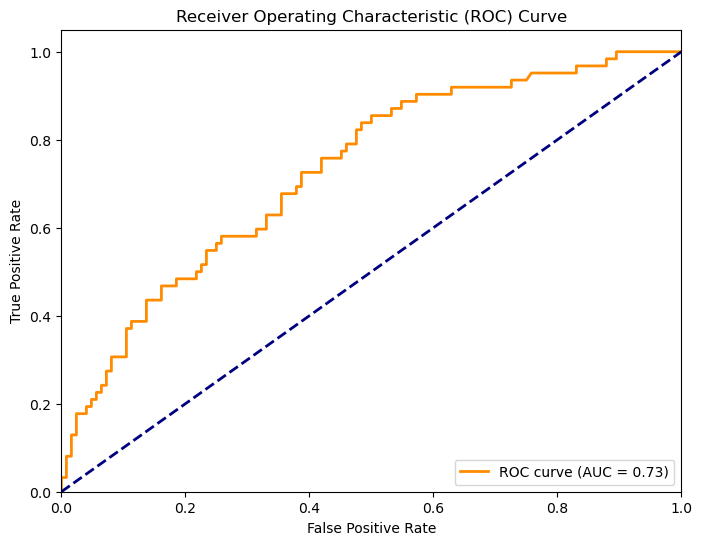

1/1 [==============================] - 0s 12ms/step


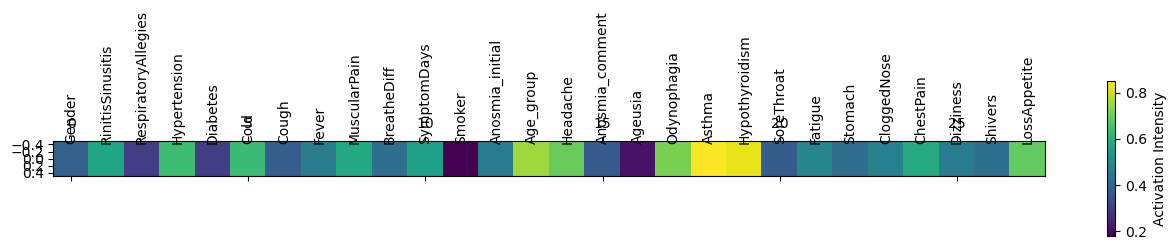

6/6 [==============================] - 0s 396us/step


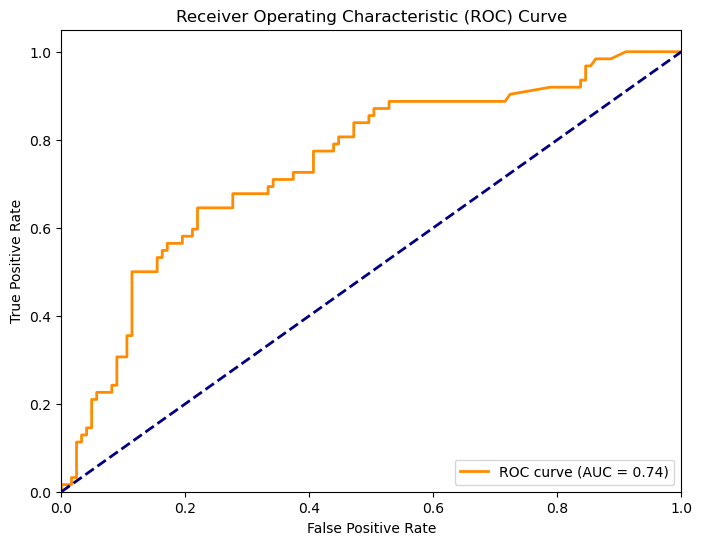

1/1 [==============================] - 0s 12ms/step


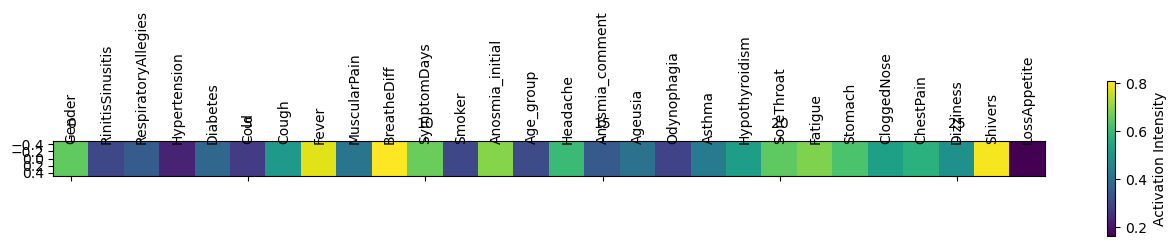

6/6 [==============================] - 0s 395us/step


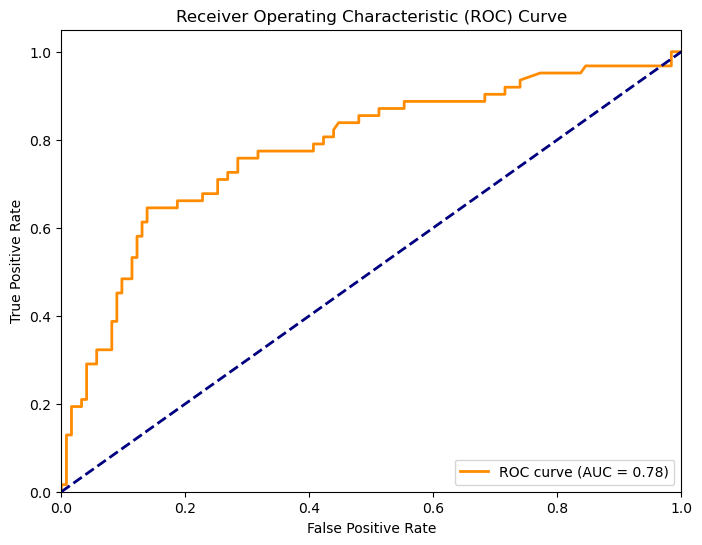

1/1 [==============================] - 0s 12ms/step


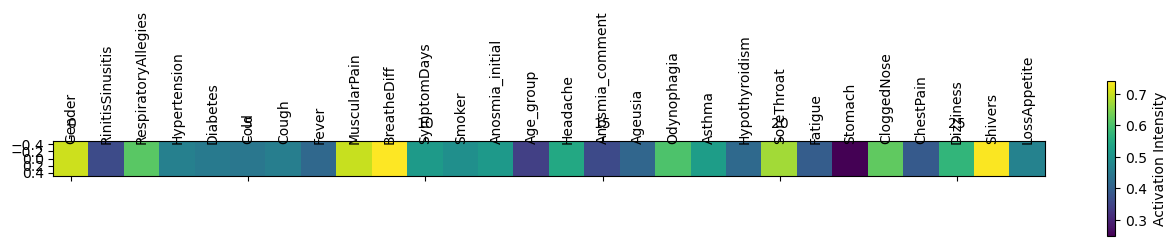

6/6 [==============================] - 0s 892us/step


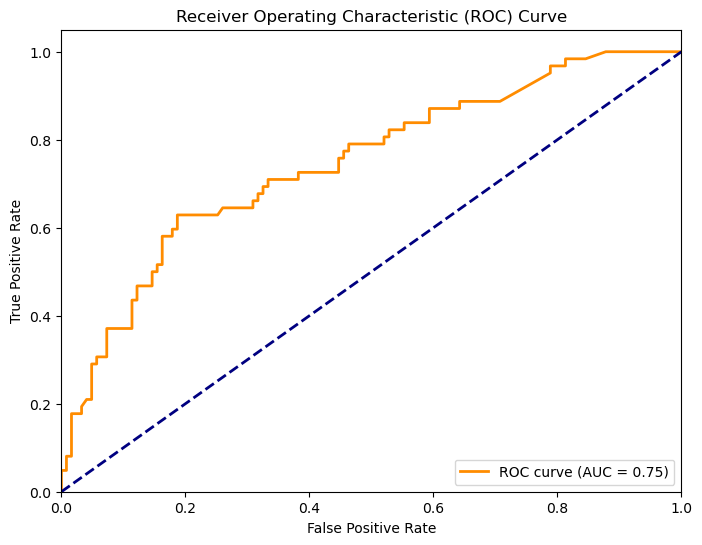

1/1 [==============================] - 0s 11ms/step


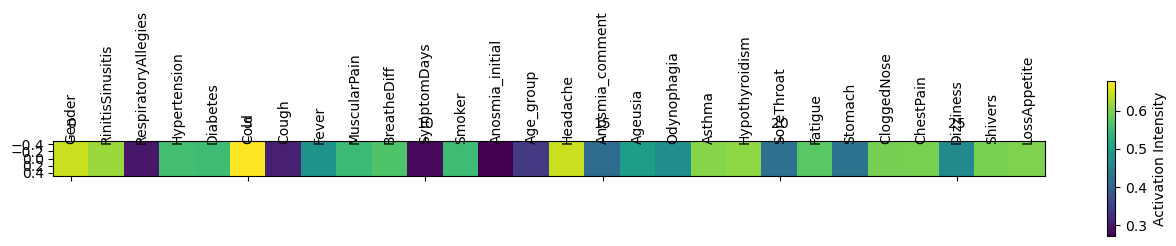

6/6 [==============================] - 0s 413us/step


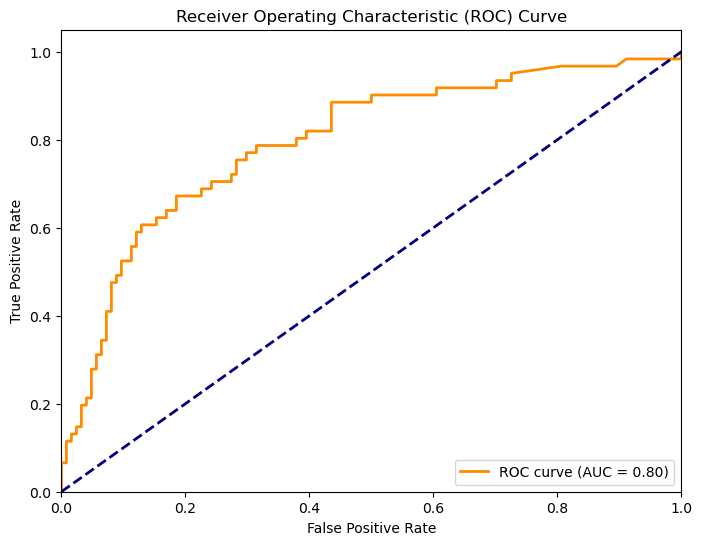

Average ROC AUC: 0.7590116520162661


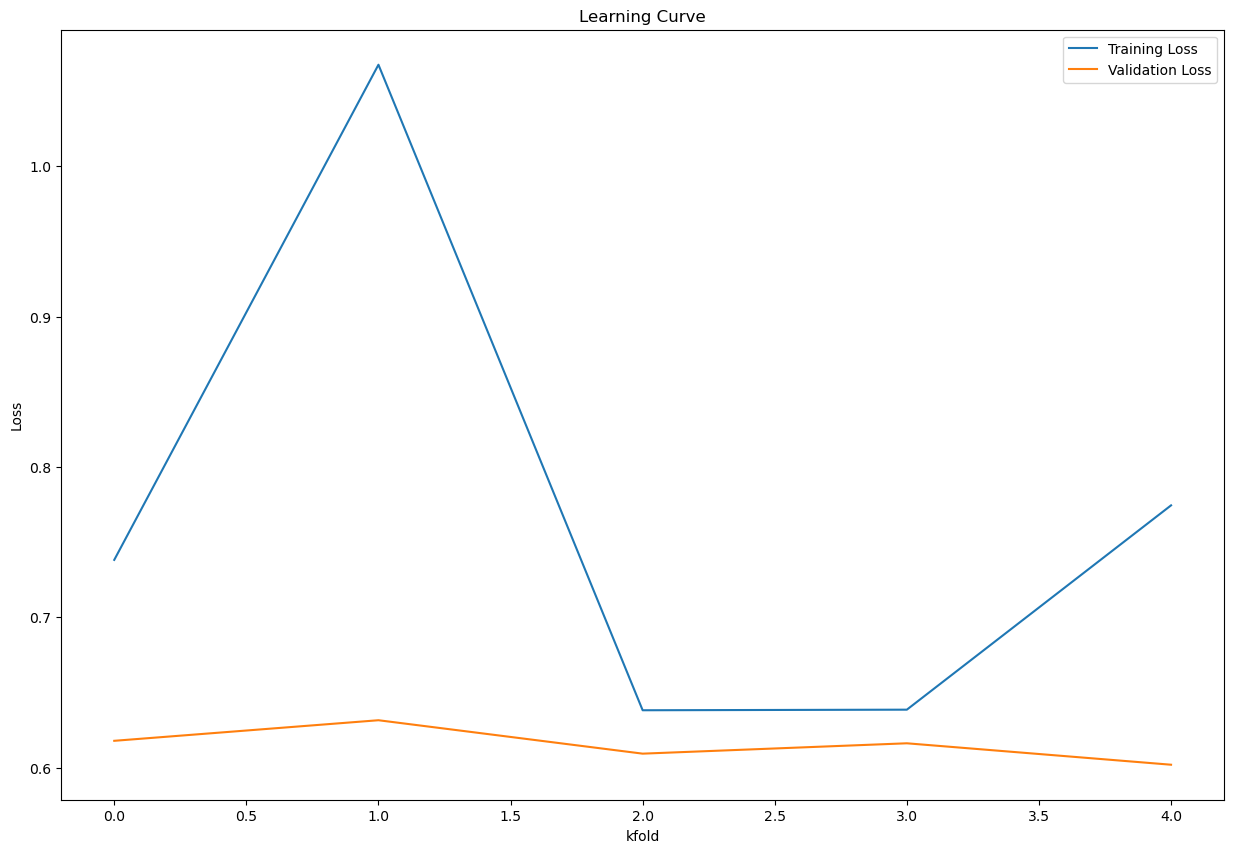

In [226]:
from sklearn.model_selection import KFold
from sklearn.model_selection import KFold
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt

#defining features and target

roc_auc_scores = []
tpr_list = [] 
fpr_list = [] 
X = covid[features]
y = covid[target]
# K-Fold Cross-Validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
accuracies = []
train_losses=[]
val_losses=[]
for train_idx, val_idx in kfold.split(X,y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(28, activation='sigmoid', input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(9, activation='sigmoid'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    history=model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
    train_losses.append(history.history['loss'][0])
    
    accuracy = model.evaluate(X_val, y_val)[1]
    
    val_losses.append(model.evaluate(X_val, y_val)[0])
    accuracies.append(accuracy)
    
    
    layer_to_visualize = model.layers[0]
    
    # Create a model to output the activations of the chosen layer
    activation_model = tf.keras.Model(inputs=model.input, outputs=layer_to_visualize.output)
    
    # Get activations for a sample data point (X_val[0] or any other sample)
    sample_activations = activation_model.predict(np.expand_dims(X_val.iloc[0], axis=0))
    # Assuming sample_activations is of shape (width,)
    sample_activations_reshaped = sample_activations.reshape(1, -1)  # Reshape to (1, width)
    plt.matshow(sample_activations_reshaped, cmap='viridis')
    plt.colorbar(label='Activation Intensity')

    feature_names = features
    for i in range(len(feature_names)):
        plt.annotate(feature_names[i], (i, -0.5), rotation='vertical', ha='center')
    plt.show()
    
    
    
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
    y_pred_prob = model.predict(X_val)
    
    # Compute ROC curve and AUC for the current fold
    fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    roc_auc_scores.append(roc_auc)
    
    tpr_list.append(tpr)
    fpr_list.append(fpr)
    # Plot the average ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()
    
    
    
    
    
    
    
    


average_accuracy = np.mean(accuracies)
#print(f'Average Cross-Validation Accuracy: {average_accuracy:.2f}')train_losses.append(history.history['loss'][0]) 
average_roc_auc = sum(roc_auc_scores) / len(roc_auc_scores)
print("Average ROC AUC:", average_roc_auc)
plt.figure(figsize=(15, 10))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.title('Learning Curve')
plt.xlabel('kfold')
plt.ylabel('Loss')
plt.legend()
plt.show()






In [227]:
cov_new = covid[['Gender', 'RinitisSinusitis', 'RespiratoryAllegies', 'Hypertension', 'Diabetes', 'Cold', 'Cough', 'BreatheDiff', 'SymptomDays', 'Smoker', 'COVI19_PCR', 'Age_group', 'Ageusia', 'Odynophagia', 'Asthma', 'Hypothyroidism', 'SoreThroat', 'ChestPain', 'Fever', 'Anosmia_comment']]

# Using the reduced dataset


1/1 [==============================] - 0s 13ms/step


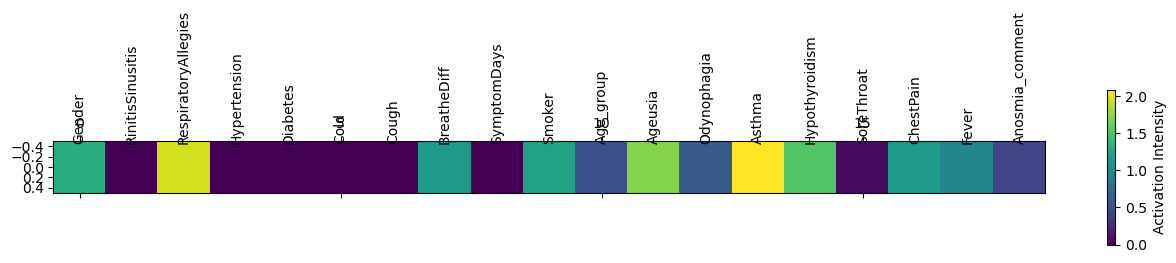

6/6 [==============================] - 0s 425us/step


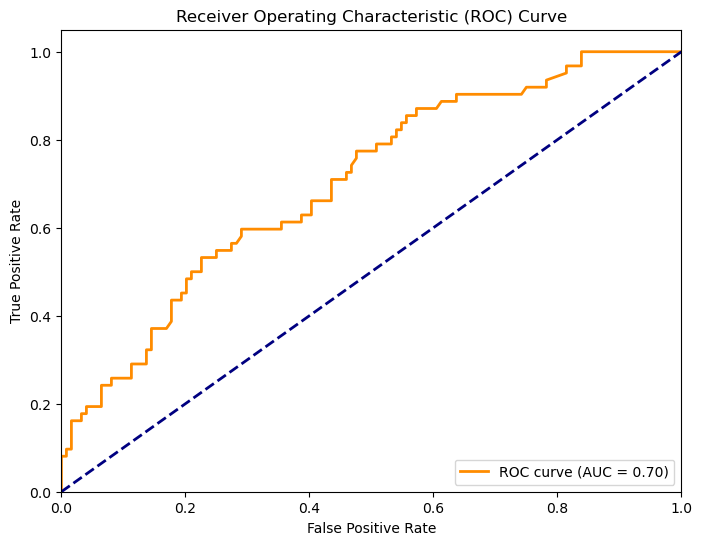

1/1 [==============================] - 0s 12ms/step


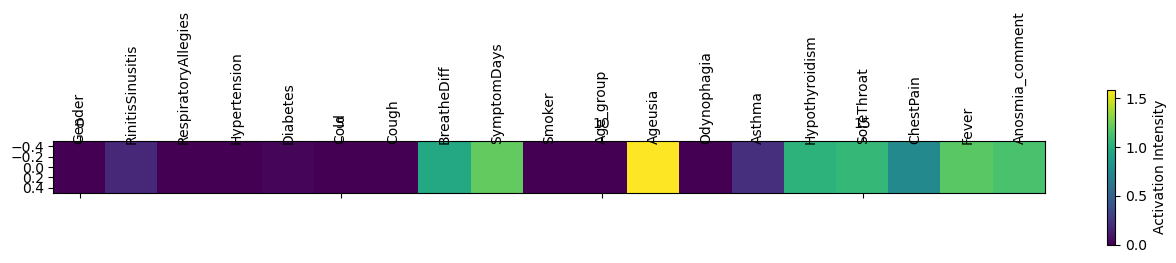

6/6 [==============================] - 0s 442us/step


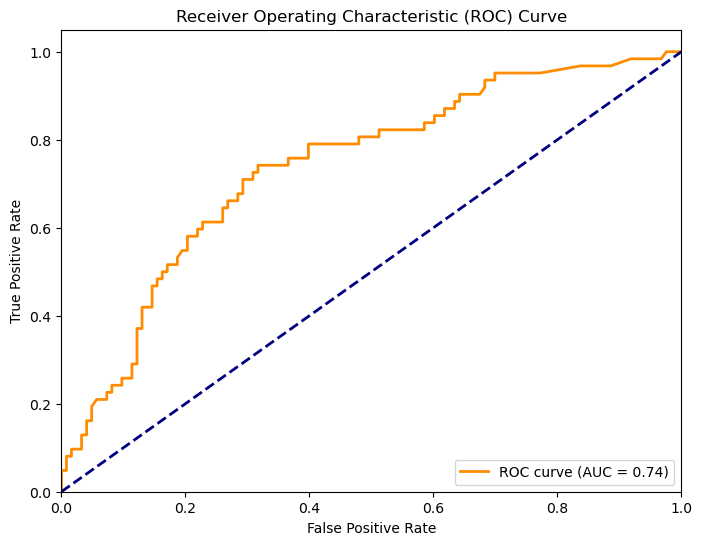

1/1 [==============================] - 0s 11ms/step


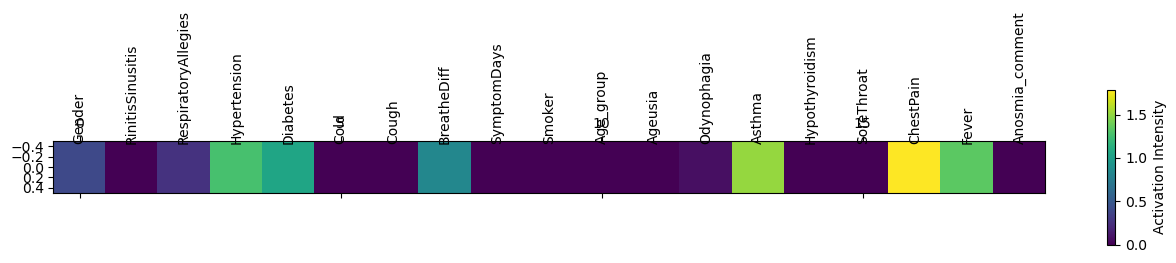

6/6 [==============================] - 0s 414us/step


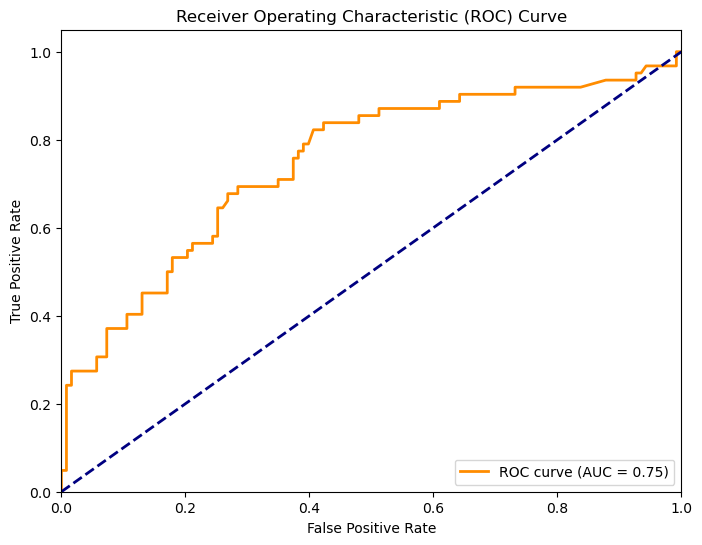

1/1 [==============================] - 0s 11ms/step


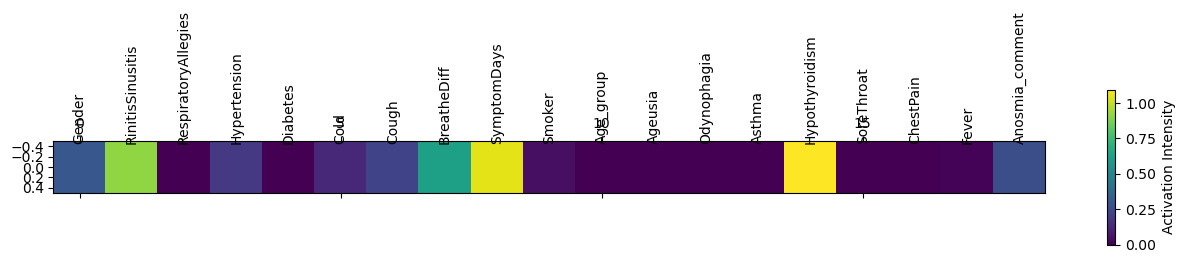

6/6 [==============================] - 0s 407us/step


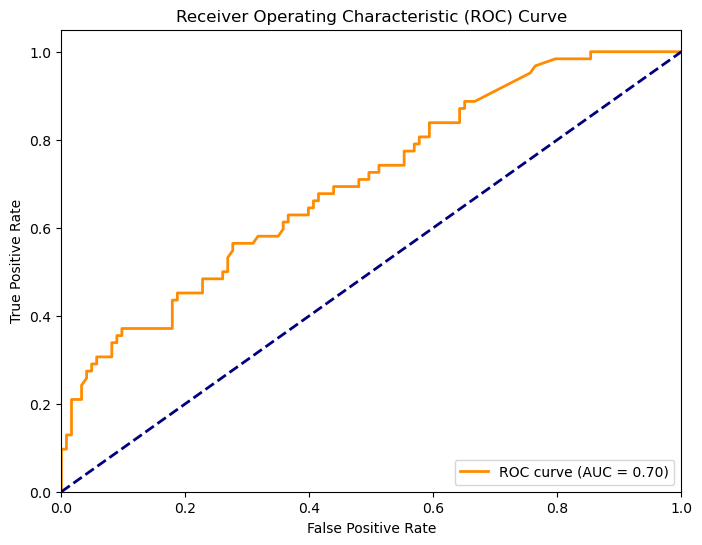

1/1 [==============================] - 0s 11ms/step


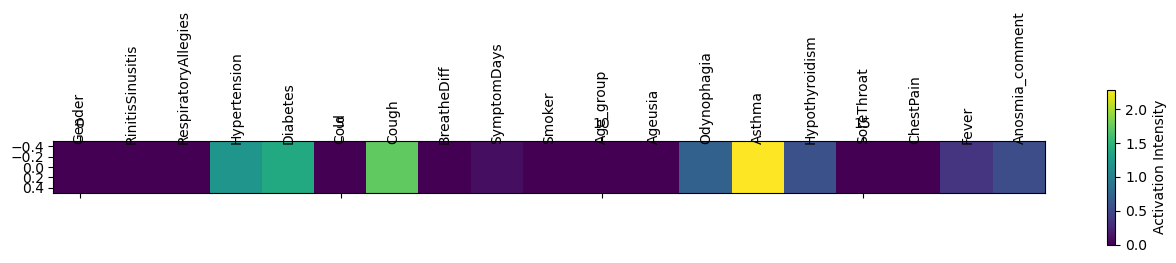

6/6 [==============================] - 0s 429us/step


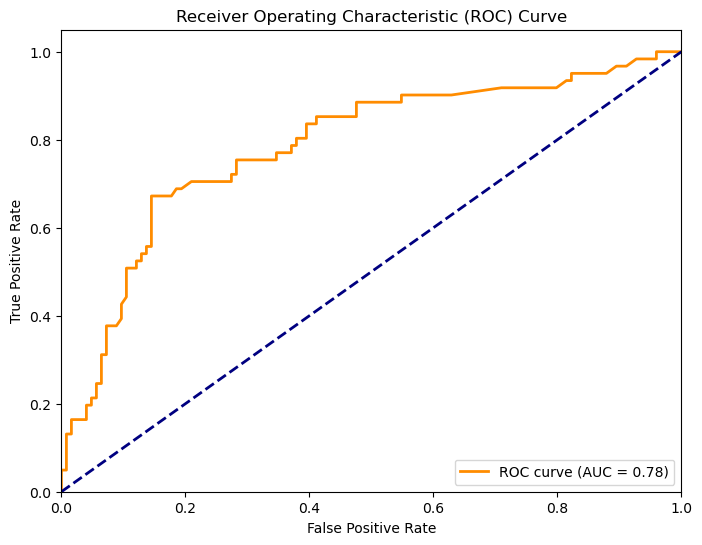

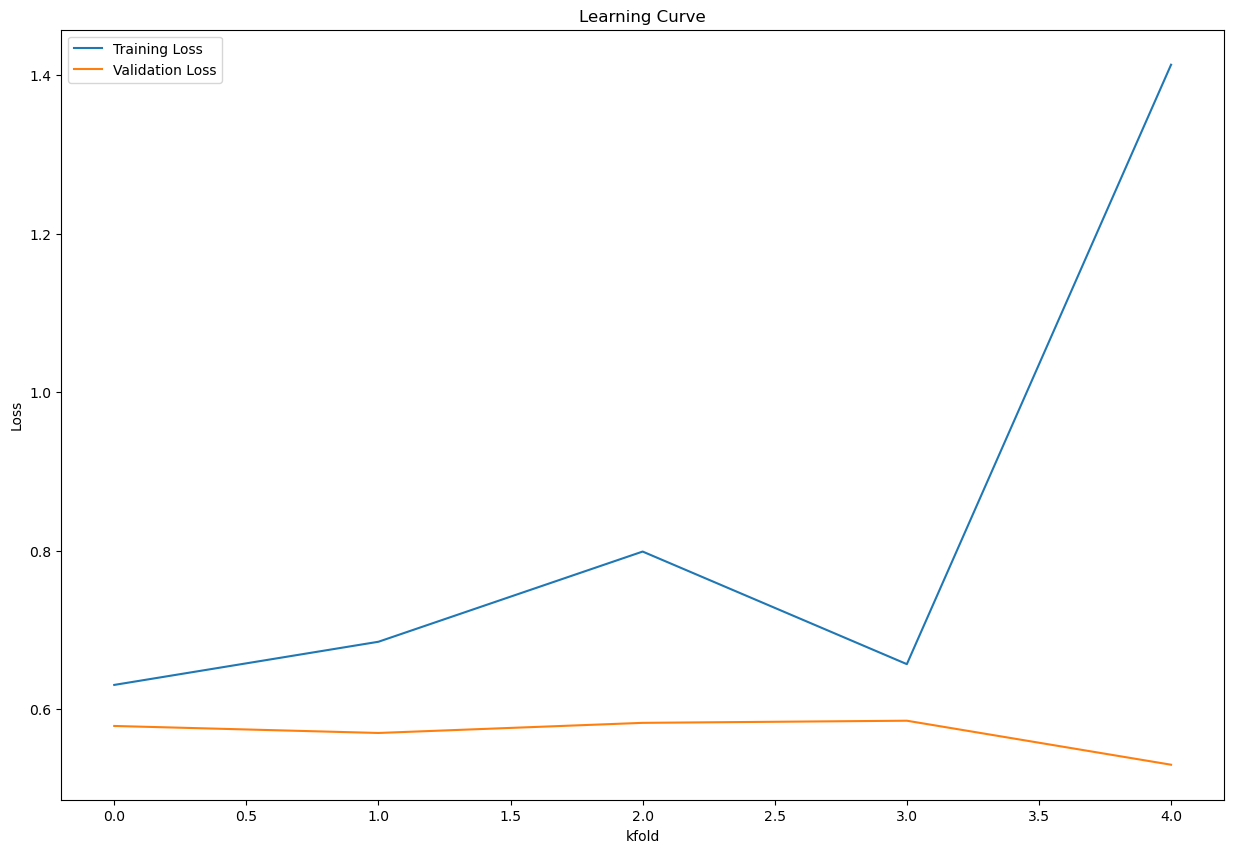

In [228]:

from sklearn.model_selection import KFold
from sklearn.model_selection import KFold
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

#defining features and target
target = "COVI19_PCR"
# Define features as all columns except the target variable
features = cov_new.drop(columns=[target]).columns.tolist()
features


roc_auc_scores = []
tpr_list = [] 
fpr_list = [] 
X = cov_new[features]
y = cov_new[target]
# K-Fold Cross-Validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
accuracies = []
train_losses=[]
val_losses=[]
for train_idx, val_idx in kfold.split(X,y):
    X_train, X_val = X.iloc[train_idx],X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(19, activation='relu', input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(10, activation='relu'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    history=model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
    train_losses.append(history.history['loss'][0])
    
    accuracy = model.evaluate(X_val, y_val)[1]
    
    val_losses.append(model.evaluate(X_val, y_val)[0])
    accuracies.append(accuracy)
    
    
    layer_to_visualize = model.layers[0]
    
    # Create a model to output the activations of the chosen layer
    activation_model = tf.keras.Model(inputs=model.input, outputs=layer_to_visualize.output)
    
    # Get activations for a sample data point (X_val[0] or any other sample)
    sample_activations = activation_model.predict(np.expand_dims(X_val.iloc[0], axis=0))
    # Assuming sample_activations is of shape (width,)
    sample_activations_reshaped = sample_activations.reshape(1, -1)  # Reshape to (1, width)
    plt.matshow(sample_activations_reshaped, cmap='viridis')
    plt.colorbar(label='Activation Intensity')

    feature_names = features
    for i in range(len(feature_names)):
        plt.annotate(feature_names[i], (i, -0.5), rotation='vertical', ha='center')
    plt.show()
    
    
    
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
    y_pred_prob = model.predict(X_val)
    
    # Compute ROC curve and AUC for the current fold
    fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    roc_auc_scores.append(roc_auc)
    
    tpr_list.append(tpr)
    fpr_list.append(fpr)
    # Plot the average ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()
    
    
    
    
    
    
    


average_accuracy = np.mean(accuracies)
#print(f'Average Cross-Validation Accuracy: {average_accuracy:.2f}')train_losses.append(history.history['loss'][0]) 
average_roc_auc = sum(roc_auc_scores) / len(roc_auc_scores)
#print("Average ROC AUC:", average_roc_auc)
plt.figure(figsize=(15, 10))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')


plt.title('Learning Curve')
plt.xlabel('kfold')
plt.ylabel('Loss')
plt.legend()
plt.show()






1/1 [==============================] - 0s 13ms/step


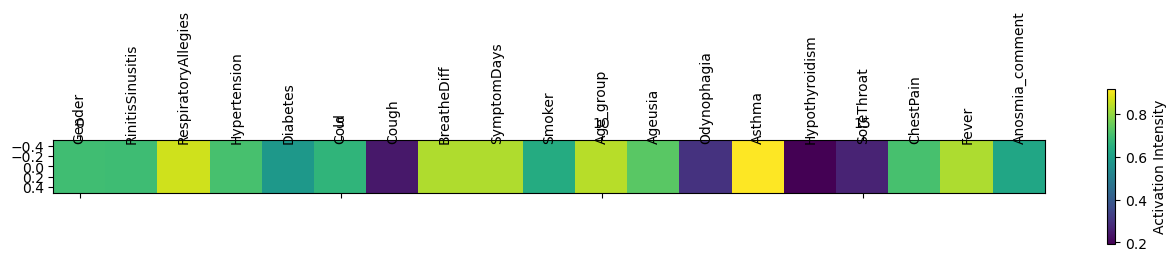

6/6 [==============================] - 0s 408us/step


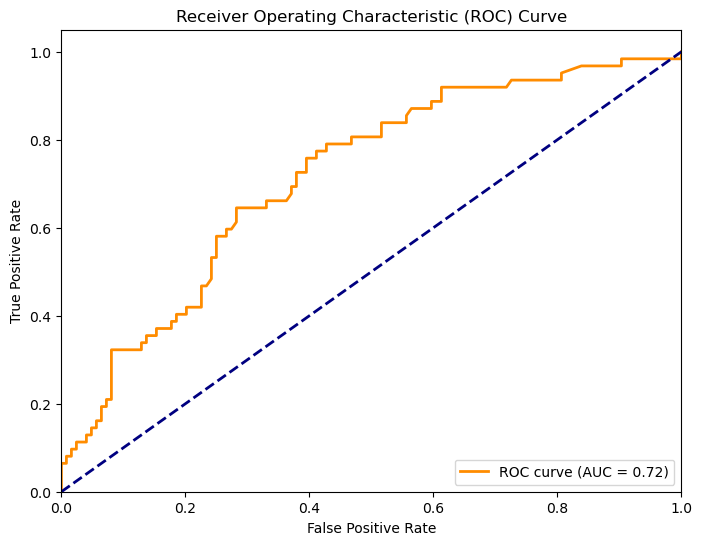

1/1 [==============================] - 0s 11ms/step


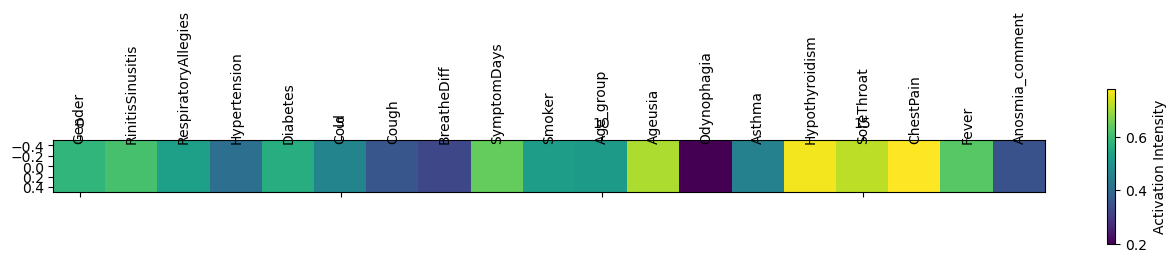

6/6 [==============================] - 0s 413us/step


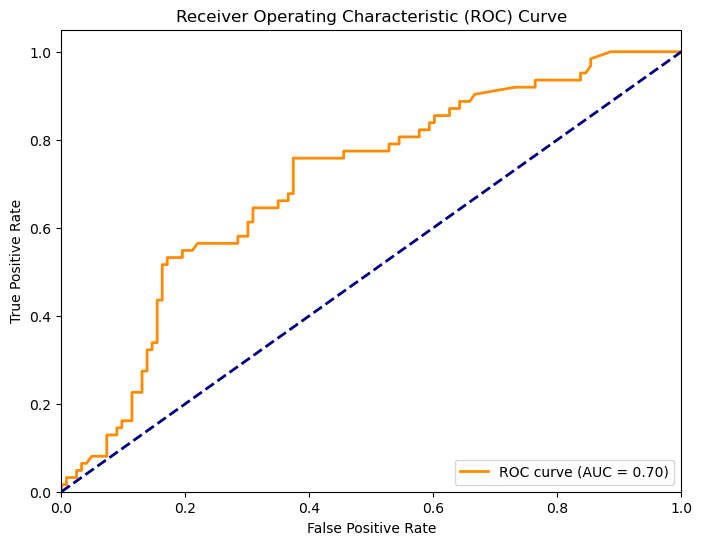

1/1 [==============================] - 0s 12ms/step


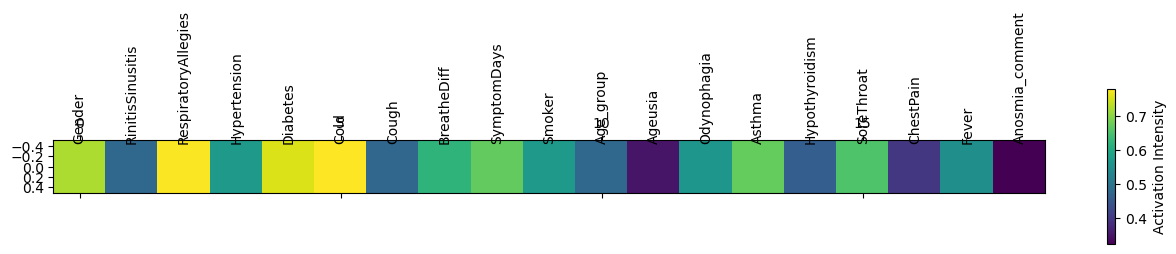

6/6 [==============================] - 0s 423us/step


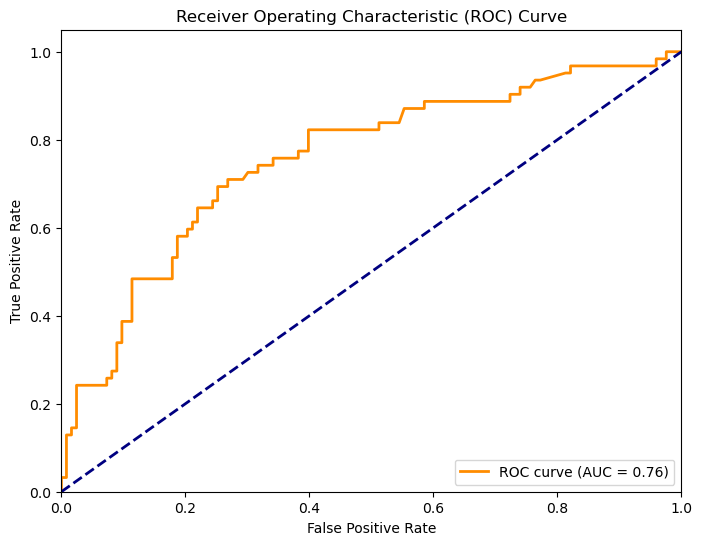

1/1 [==============================] - 0s 11ms/step


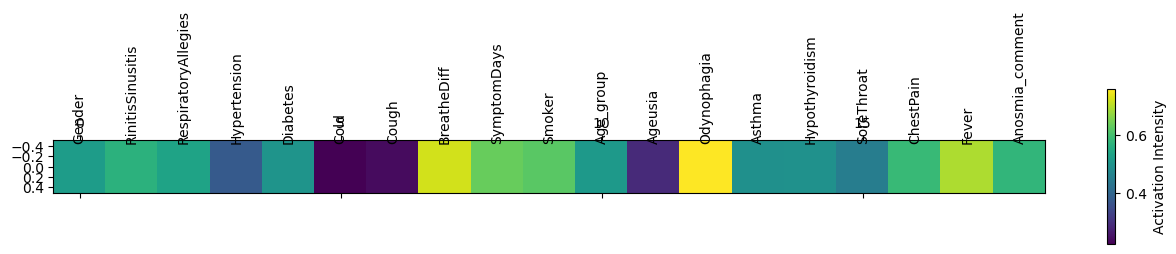

6/6 [==============================] - 0s 378us/step


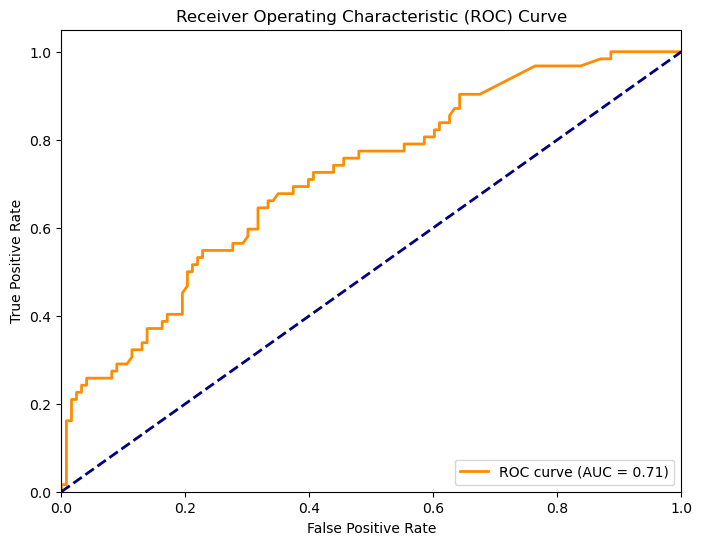

1/1 [==============================] - 0s 11ms/step


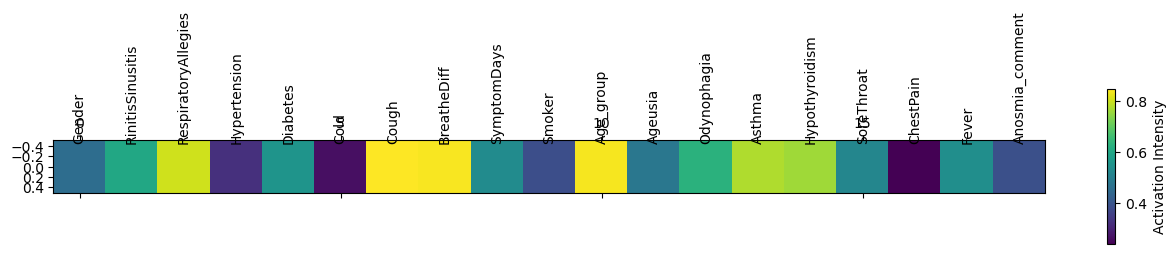

6/6 [==============================] - 0s 415us/step


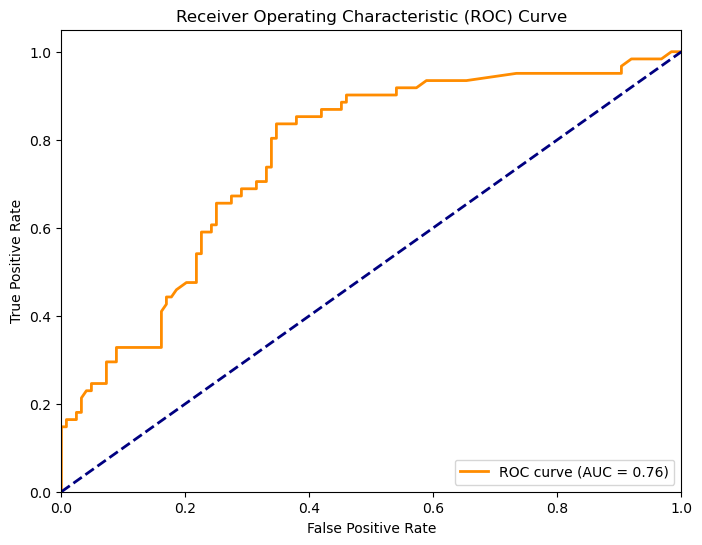

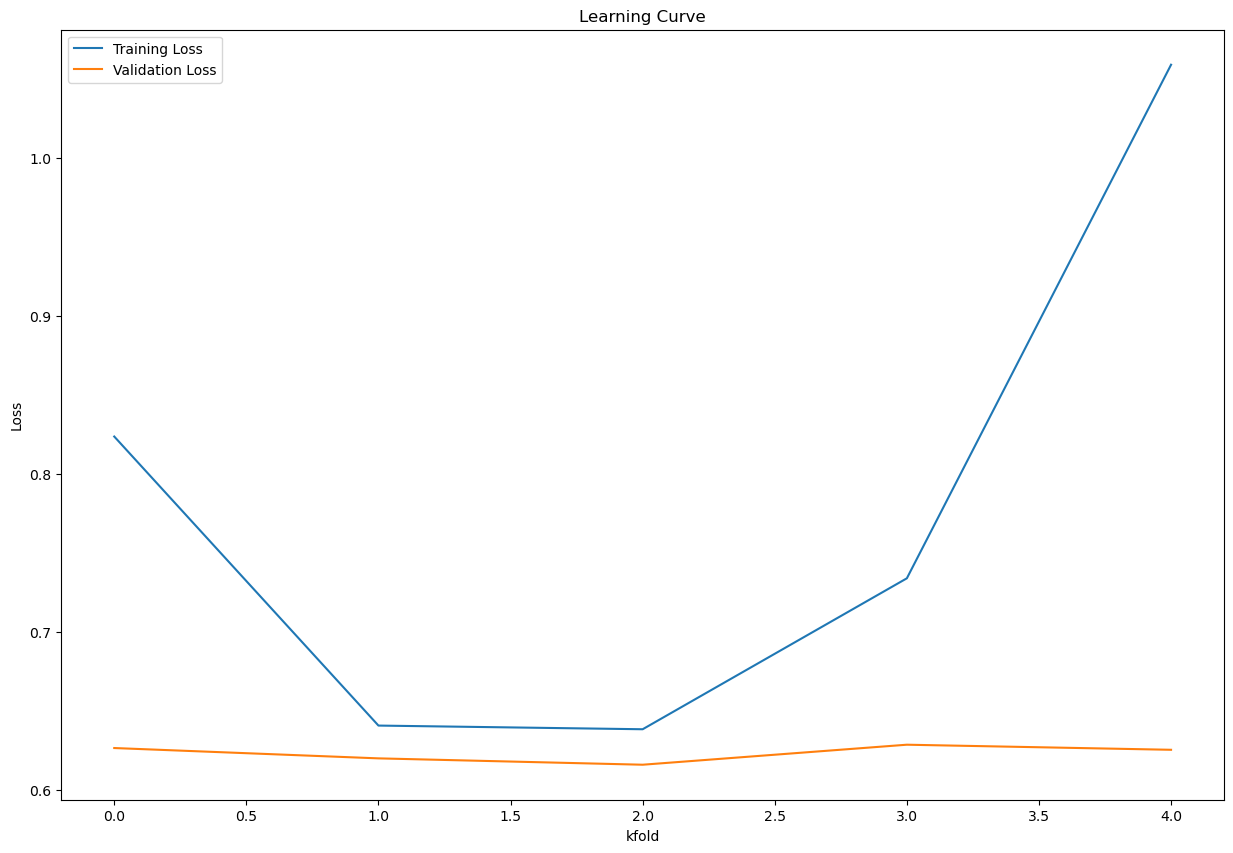

0.6663062930107116


In [229]:

from sklearn.model_selection import KFold
from sklearn.model_selection import KFold
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.regularizers import l2
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold

#defining features and target
target = "COVI19_PCR"
# Define features as all columns except the target variable
features = cov_new.drop(columns=[target]).columns.tolist()
features


roc_auc_scores = []
tpr_list = [] 
fpr_list = [] 
X = cov_new[features]
y = cov_new[target]
# K-Fold Cross-Validation
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
accuracies = []
train_losses=[]
val_losses=[]
for train_idx, val_idx in kfold.split(X,y):
    X_train, X_val = X.iloc[train_idx],X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(19, activation='sigmoid', input_shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(10, activation='sigmoid'),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    history=model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
    train_losses.append(history.history['loss'][0])
    
    accuracy = model.evaluate(X_val, y_val)[1]
    
    val_losses.append(model.evaluate(X_val, y_val)[0])
    accuracies.append(accuracy)
    
    
    layer_to_visualize = model.layers[0]
    
    # Create a model to output the activations of the chosen layer
    activation_model = tf.keras.Model(inputs=model.input, outputs=layer_to_visualize.output)
    
    # Get activations for a sample data point (X_val[0] or any other sample)
    sample_activations = activation_model.predict(np.expand_dims(X_val.iloc[0], axis=0))
    # Assuming sample_activations is of shape (width,)
    sample_activations_reshaped = sample_activations.reshape(1, -1)  # Reshape to (1, width)
    plt.matshow(sample_activations_reshaped, cmap='viridis')
    plt.colorbar(label='Activation Intensity')

    feature_names = features
    for i in range(len(feature_names)):
        plt.annotate(feature_names[i], (i, -0.5), rotation='vertical', ha='center')
    plt.show()
    
    
    
    model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)
    y_pred_prob = model.predict(X_val)
    
    # Compute ROC curve and AUC for the current fold
    fpr, tpr, thresholds = roc_curve(y_val, y_pred_prob)
    roc_auc = auc(fpr, tpr)
    roc_auc_scores.append(roc_auc)
    
    tpr_list.append(tpr)
    fpr_list.append(fpr)
    # Plot the average ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()
    
    
    
    
    
    
    


average_accuracy = np.mean(accuracies)
#print(f'Average Cross-Validation Accuracy: {average_accuracy:.2f}')train_losses.append(history.history['loss'][0]) 
average_roc_auc = sum(roc_auc_scores) / len(roc_auc_scores)
#print("Average ROC AUC:", average_roc_auc)
plt.figure(figsize=(15, 10))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')


plt.title('Learning Curve')
plt.xlabel('kfold')
plt.ylabel('Loss')
plt.legend()
plt.show()


print(average_accuracy)



SVM

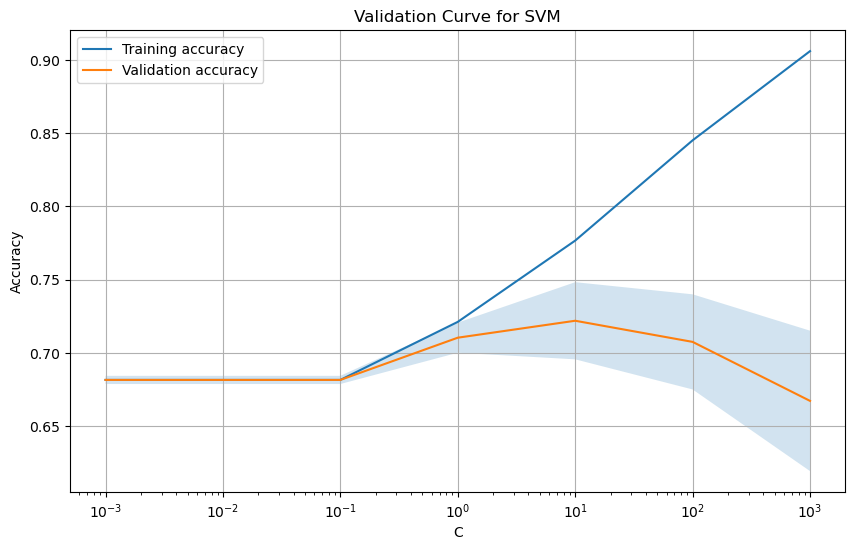

In [230]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(cov_new[features], cov_new[target], test_size = 0.25)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import validation_curve
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

# Assuming 'X_train', 'y_train' are defined
param_range = np.logspace(-3, 3, 7)  # Range of C values to explore

# Calculate validation curve
train_scores, test_scores = validation_curve(
    SVC(kernel='rbf', random_state=0), X_train, y_train, 
    param_name='C', param_range=param_range, cv=5, scoring='accuracy', n_jobs=-1
)

# Calculate mean and standard deviation of scores
mean_train_scores = np.mean(train_scores, axis=1)
mean_test_scores = np.mean(test_scores, axis=1)
std_test_scores = np.std(test_scores, axis=1)

# Plot validation curve
plt.figure(figsize=(10, 6))
plt.semilogx(param_range, mean_train_scores, label='Training accuracy')
plt.semilogx(param_range, mean_test_scores, label='Validation accuracy')
plt.fill_between(param_range, mean_test_scores - std_test_scores, mean_test_scores + std_test_scores, alpha=0.2)
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.title('Validation Curve for SVM')
plt.legend()
plt.grid(True)
plt.show()




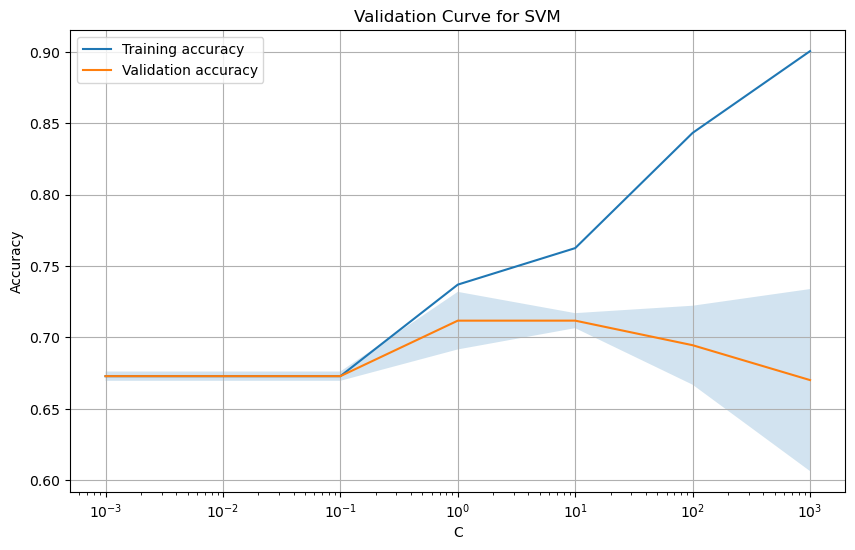

In [231]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(cov_new[features], cov_new[target], test_size = 0.25)

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import validation_curve
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix

# Assuming 'X_train', 'y_train' are defined
param_range = np.logspace(-3, 3, 7)  # Range of C values to explore

# Calculate validation curve
train_scores, test_scores = validation_curve(
    SVC(kernel='rbf', random_state=0), X_train, y_train, 
    param_name='C', param_range=param_range, cv=5, scoring='accuracy', n_jobs=-1
)

# Calculate mean and standard deviation of scores
mean_train_scores = np.mean(train_scores, axis=1)
mean_test_scores = np.mean(test_scores, axis=1)
std_test_scores = np.std(test_scores, axis=1)

# Plot validation curve
plt.figure(figsize=(10, 6))
plt.semilogx(param_range, mean_train_scores, label='Training accuracy')
plt.semilogx(param_range, mean_test_scores, label='Validation accuracy')
plt.fill_between(param_range, mean_test_scores - std_test_scores, mean_test_scores + std_test_scores, alpha=0.2)
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.title('Validation Curve for SVM')
plt.legend()
plt.grid(True)
plt.show()


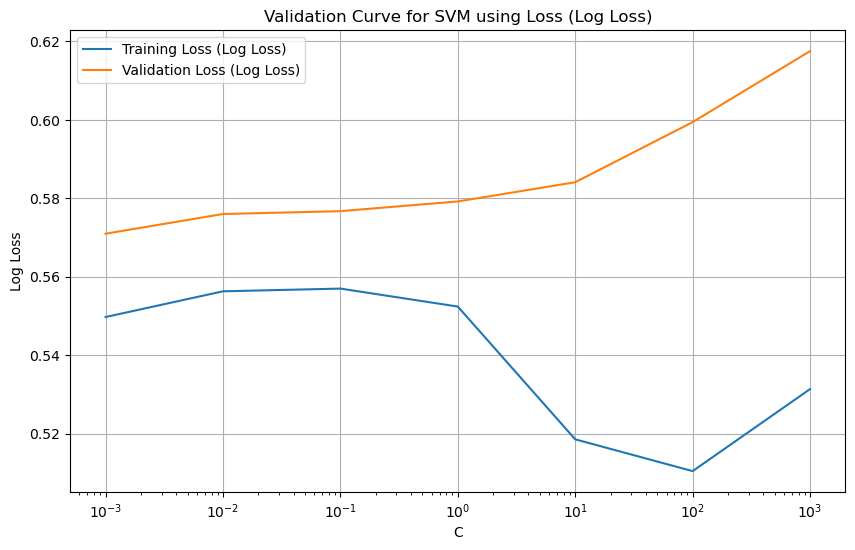

Average Accuracy: 0.6806783742267614


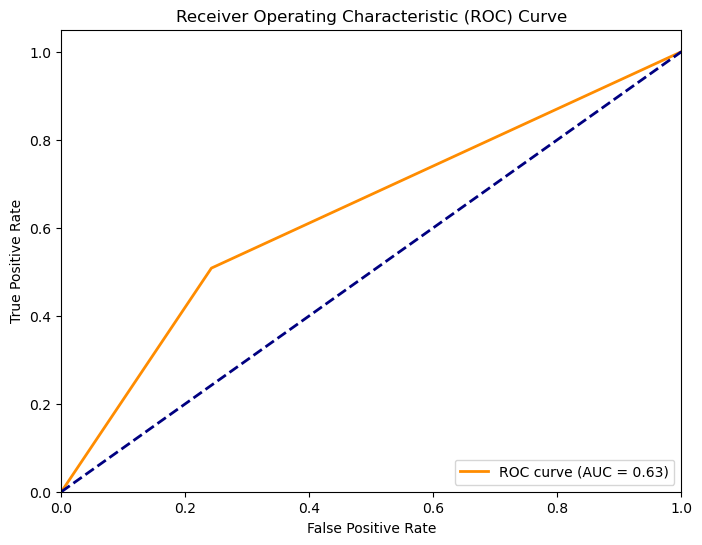

In [232]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss
from sklearn.metrics import accuracy_score
# Define the range of parameter values you want to test (e.g., C values)
param_range = np.logspace(-3, 3, 7)  # Range of C values to explore

# Initialize lists to store training and validation losses
train_losses = []
validation_losses = []
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
accuracies = []
train_losses=[]
val_losses=[]
#X = cov_new[X]
#y = cov_new[y]
fold_accuracies = []   
    
for C_value in param_range:
    # Initialize lists to store losses for each fold
    fold_train_losses = []
    fold_validation_losses = []
    
    
    for train_idx, val_idx in kfold.split(X,y):
        X_train, X_val =X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # Train an SVM with the current C value
        svm = SVC(kernel='rbf', C=C_value, random_state=0,probability=True)
        svm.fit(X_train, y_train)
        y_pred = svm.predict(X_val)
        accuracy = accuracy_score(y_val, y_pred)
        fold_accuracies.append(accuracy)
        
        fpr, tpr, thresholds = roc_curve(y_val, y_pred)
        roc_auc = auc(fpr, tpr)
        
        # Calculate training and validation losses (log loss in this case)
        train_loss = log_loss(y_train, svm.predict_proba(X_train))
        validation_loss = log_loss(y_val, svm.predict_proba(X_val))
        
        # Append the losses for this fold
        fold_train_losses.append(train_loss)
        fold_validation_losses.append(validation_loss)
        accuracy = accuracy_score(y_val, y_pred)
        fold_accuracies.append(accuracy)
        
        
        
    # Calculate the mean loss across folds for this C value
    mean_train_loss = np.mean(fold_train_losses)
    mean_validation_loss = np.mean(fold_validation_losses)
    
    # Append the mean losses to the respective lists
    train_losses.append(mean_train_loss)
    validation_losses.append(mean_validation_loss)
    

    
plt.figure(figsize=(10, 6))
plt.semilogx(param_range, train_losses, label='Training Loss (Log Loss)')
plt.semilogx(param_range, validation_losses, label='Validation Loss (Log Loss)')
plt.xlabel('C')
plt.ylabel('Log Loss')
plt.title('Validation Curve for SVM using Loss (Log Loss)')
plt.legend()
plt.grid(True)
plt.show()


average_accuracy = np.mean(fold_accuracies)
print("Average Accuracy:", average_accuracy)




# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

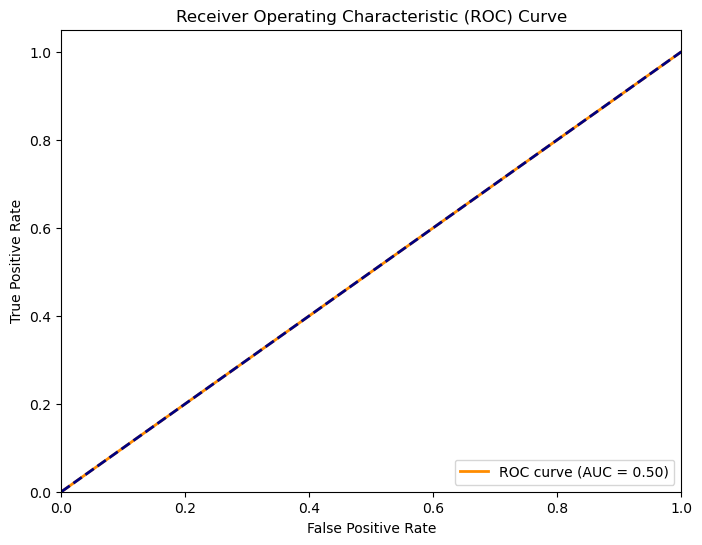

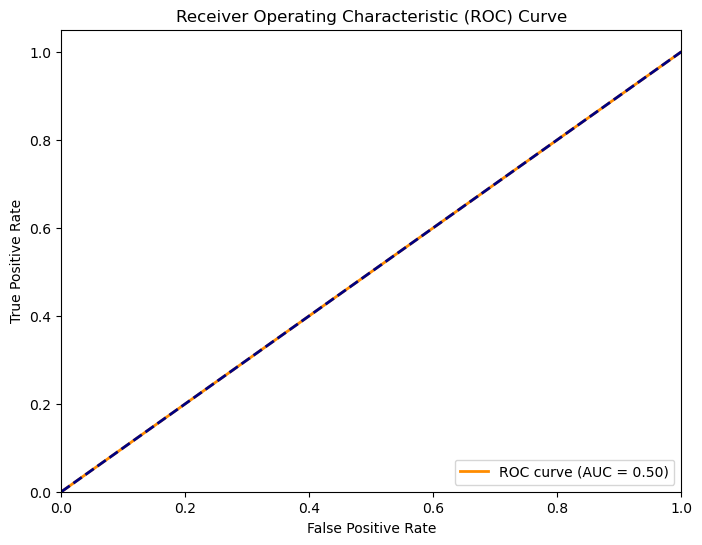

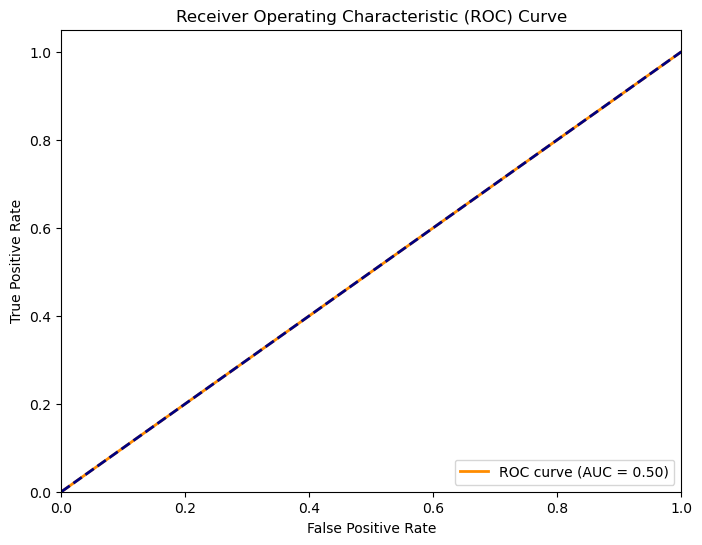

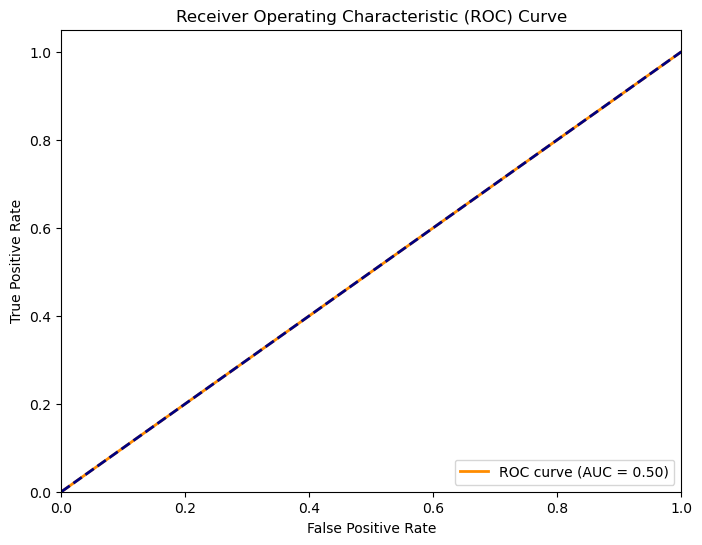

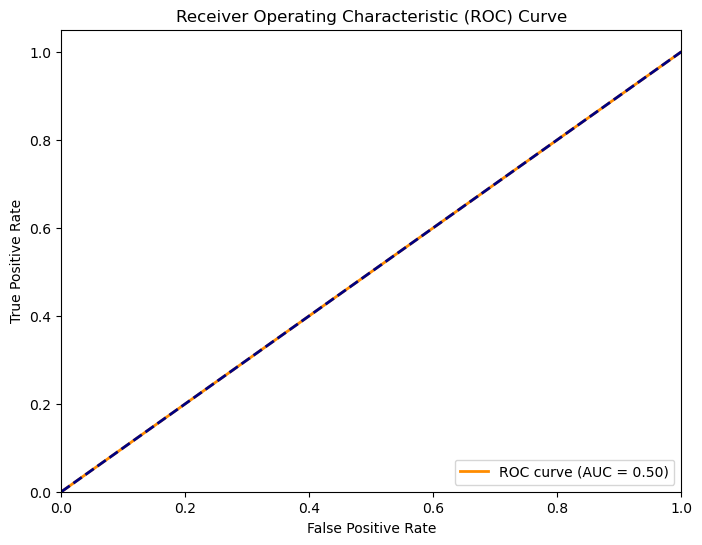

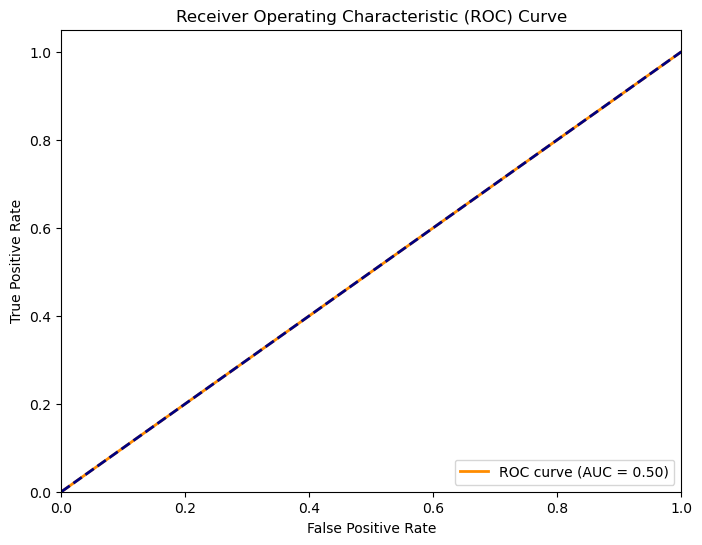

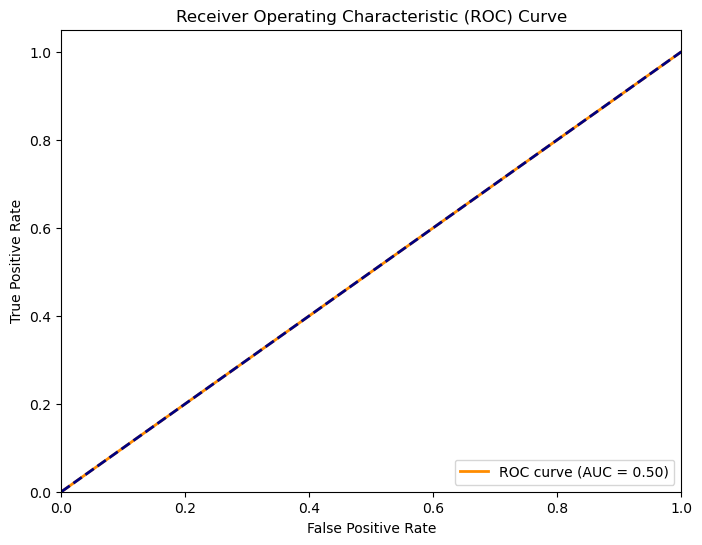

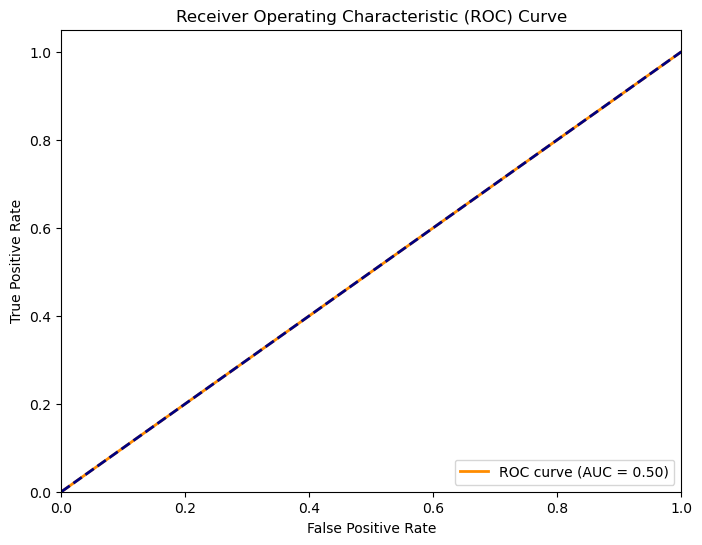

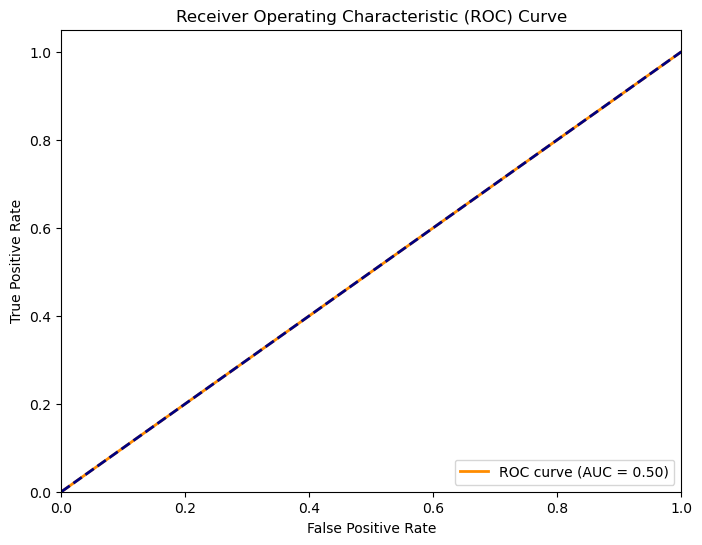

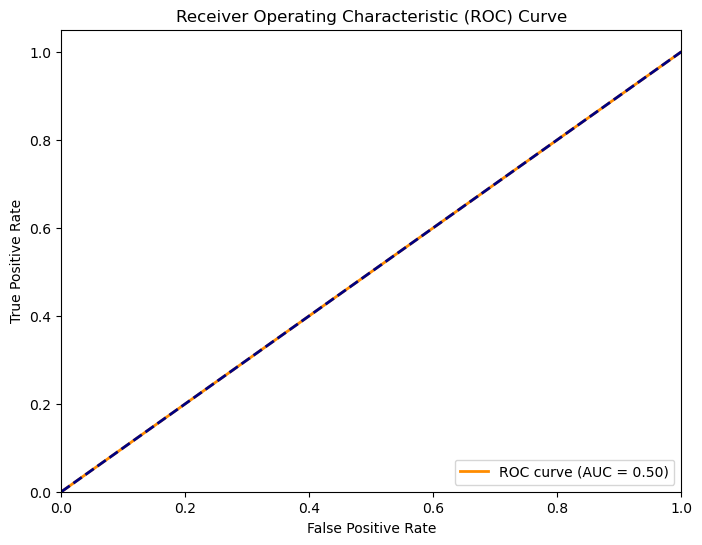

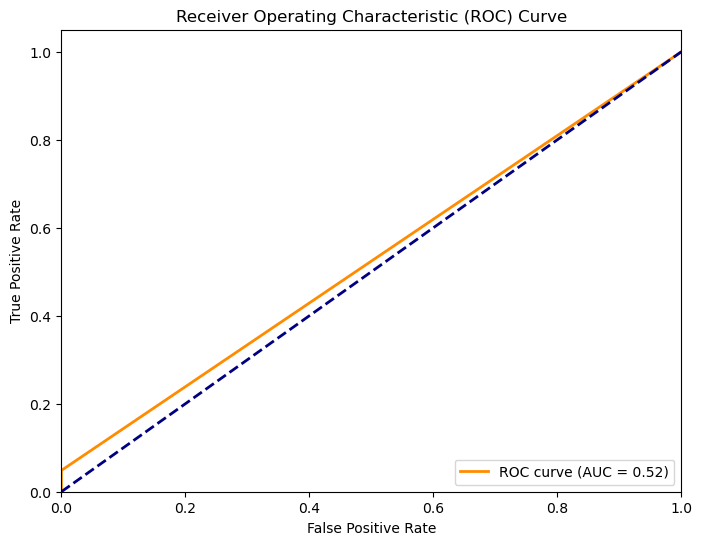

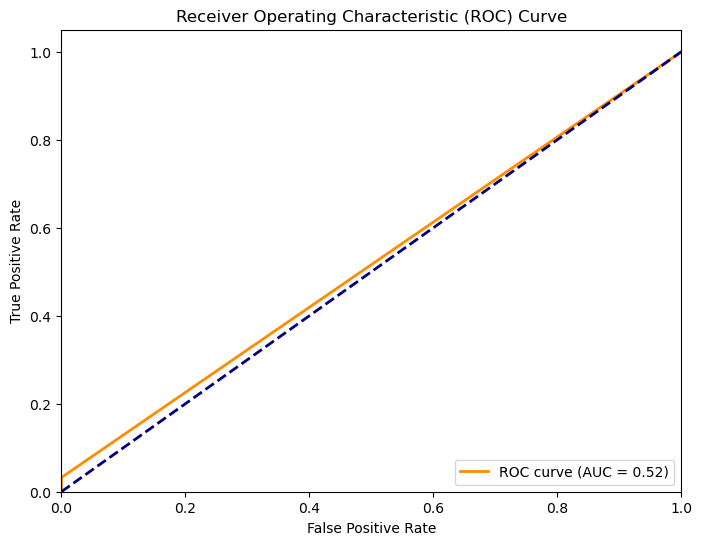

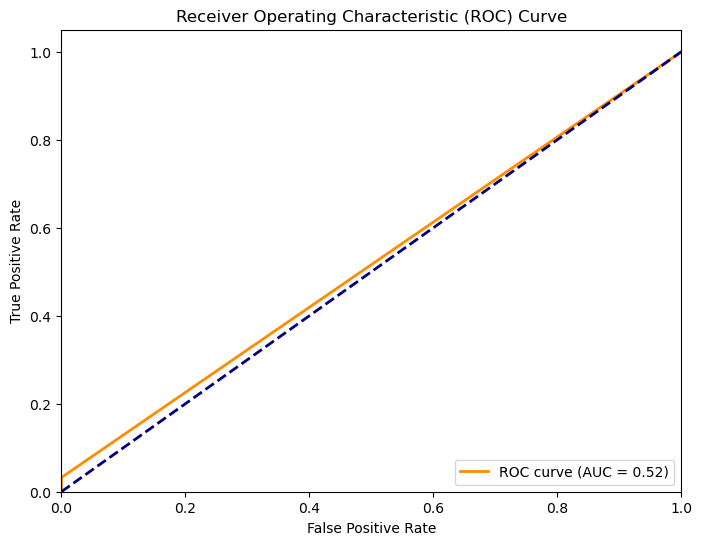

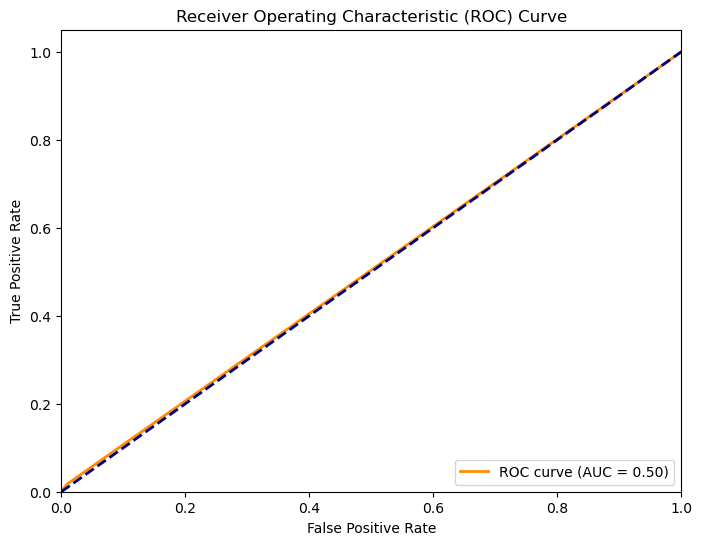

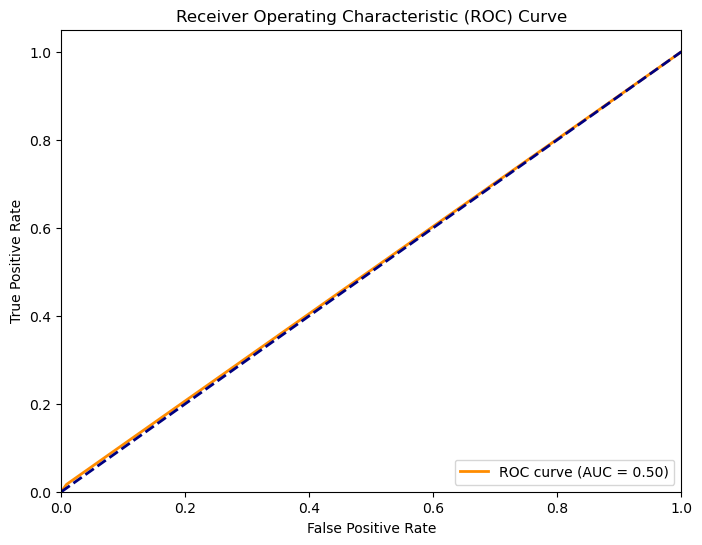

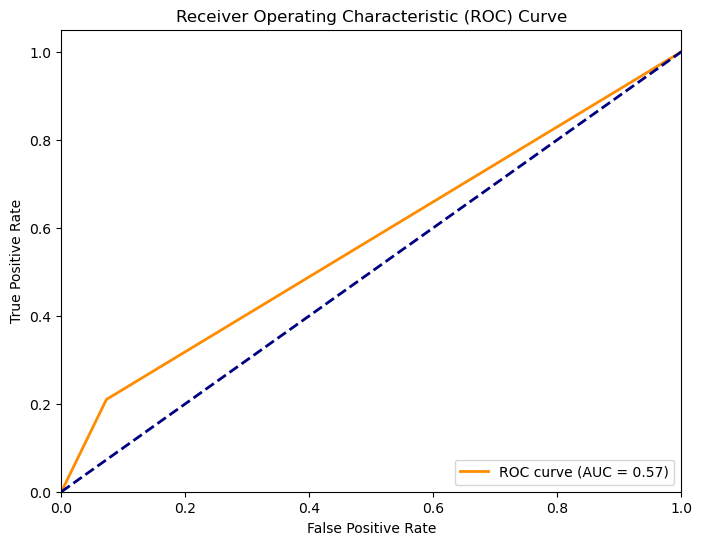

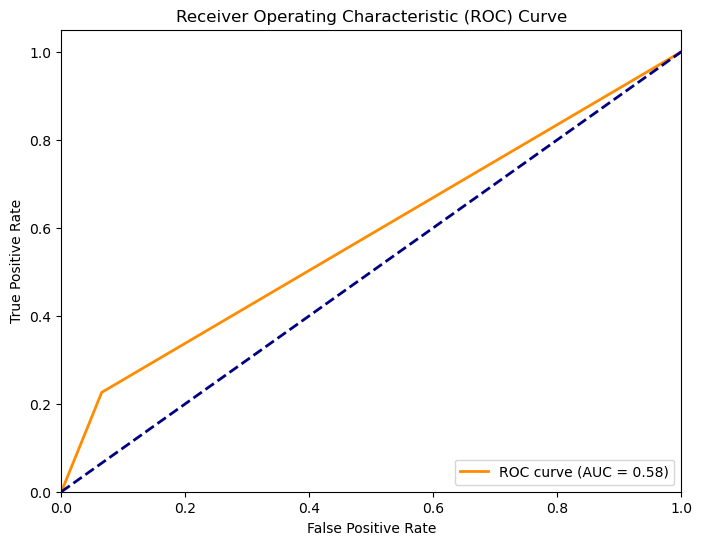

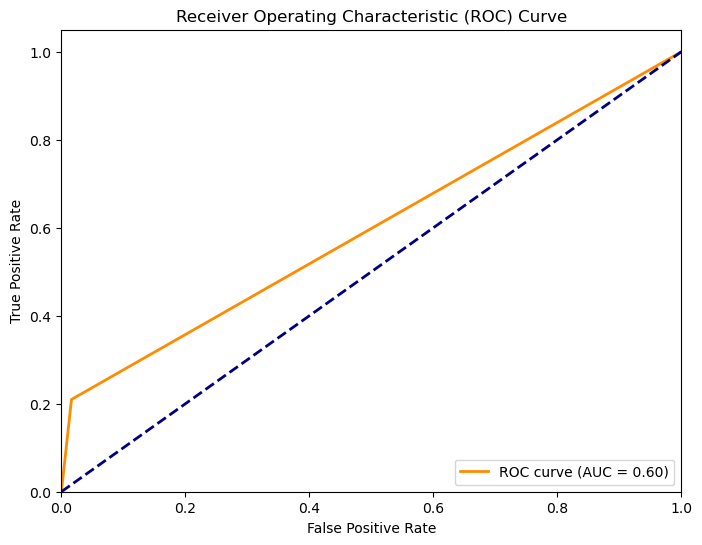

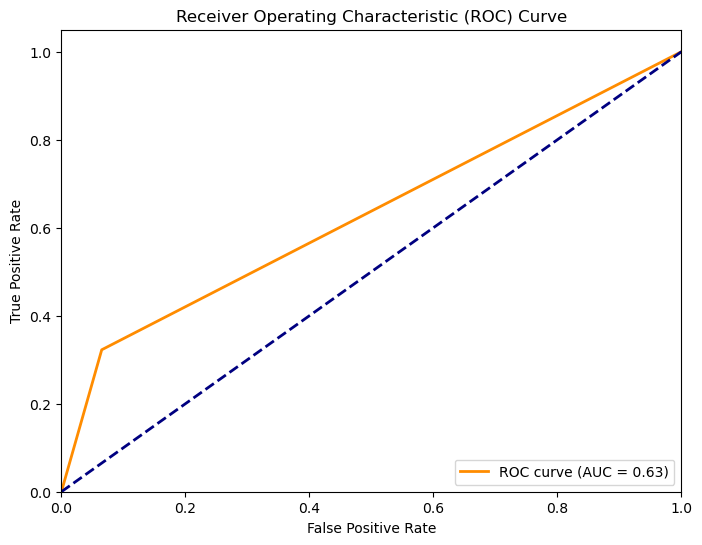

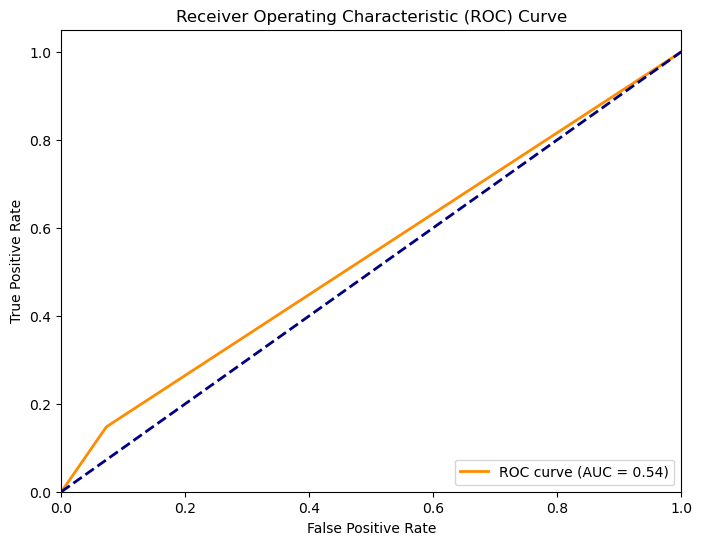

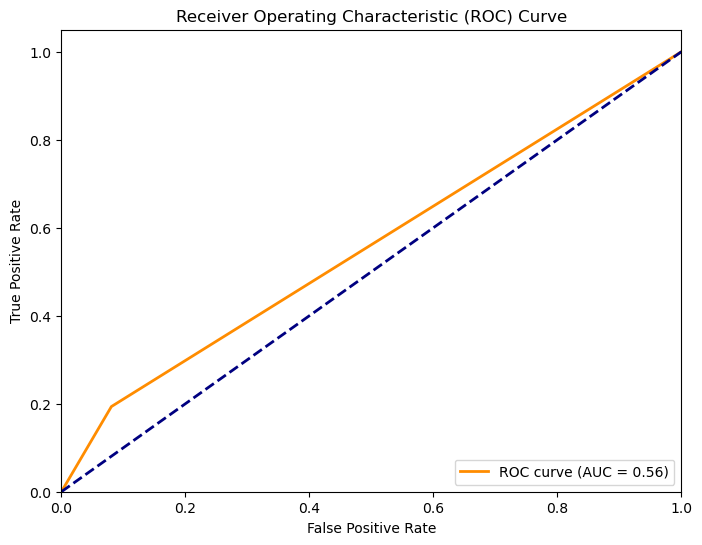

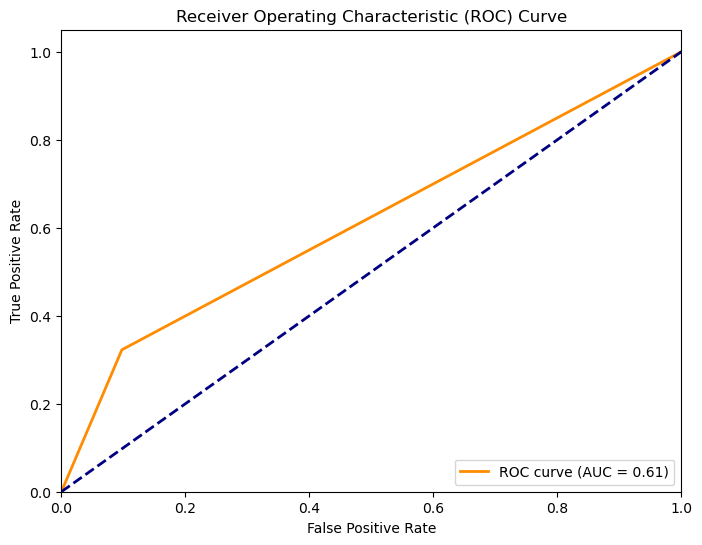

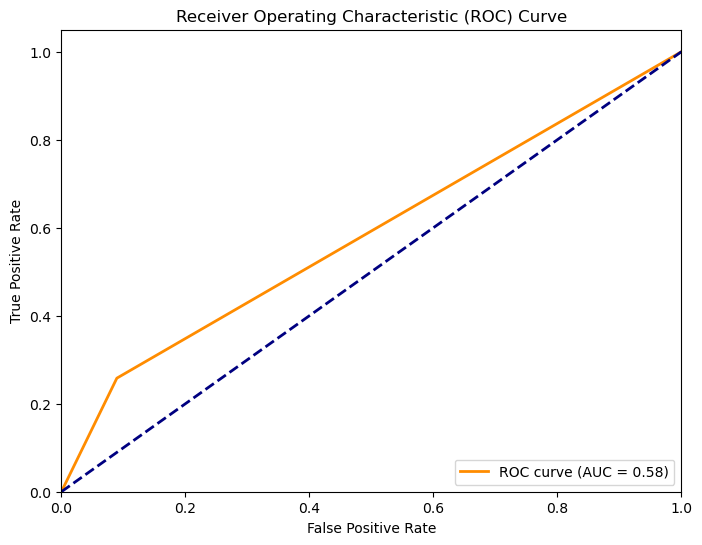

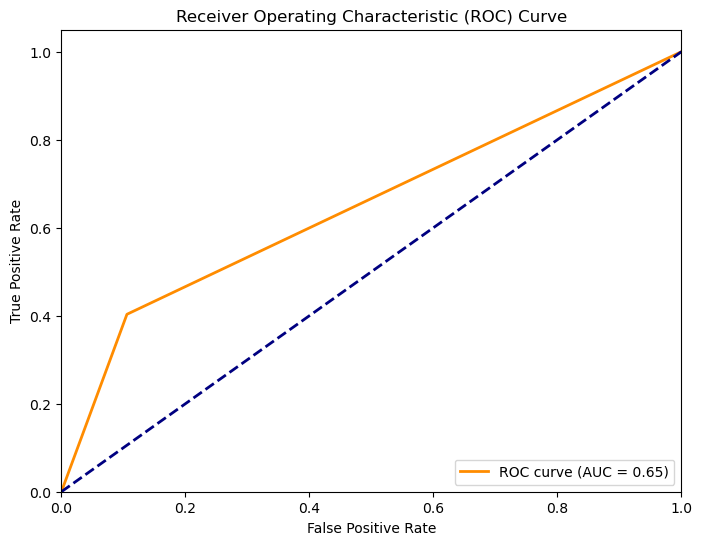

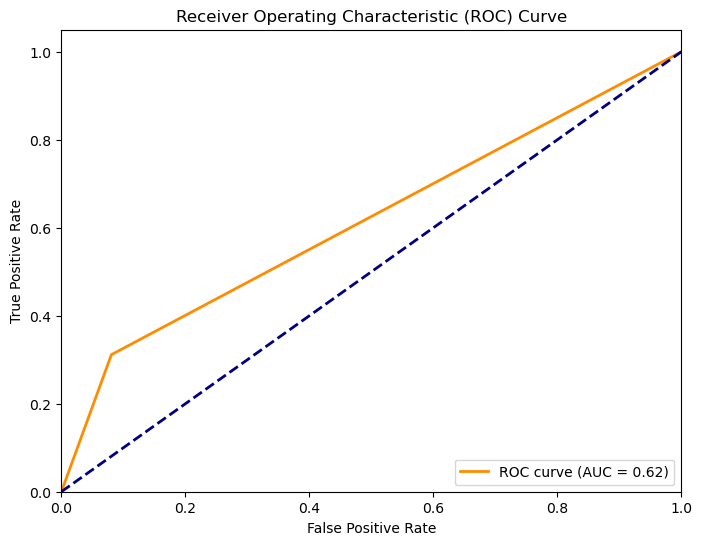

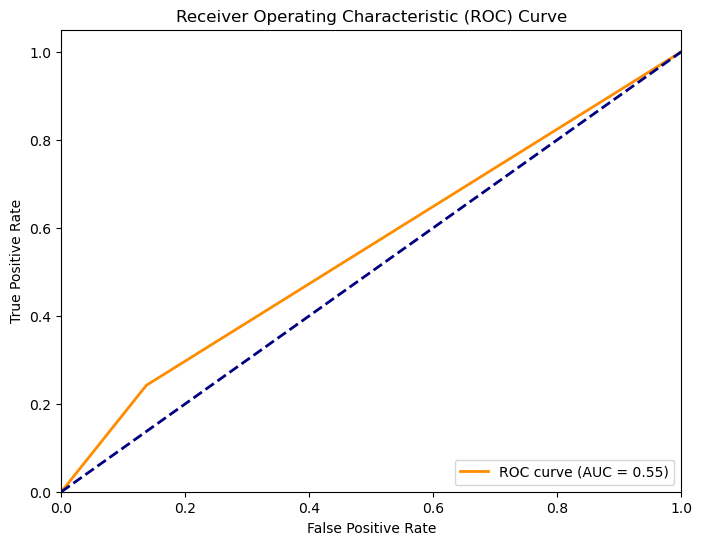

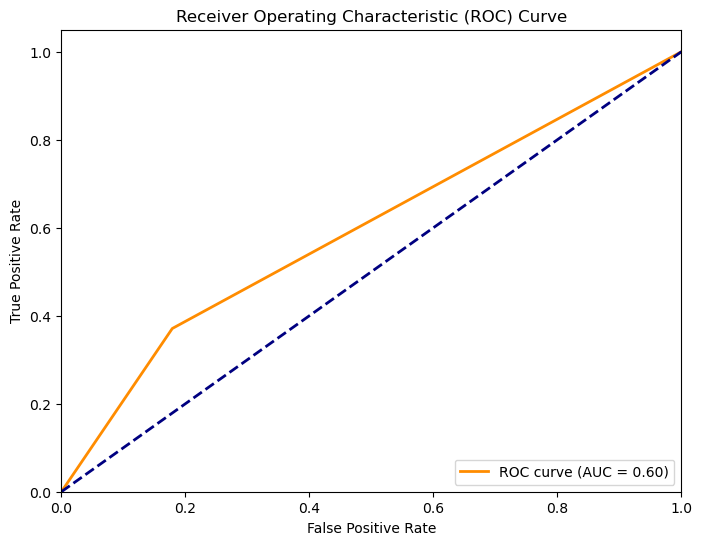

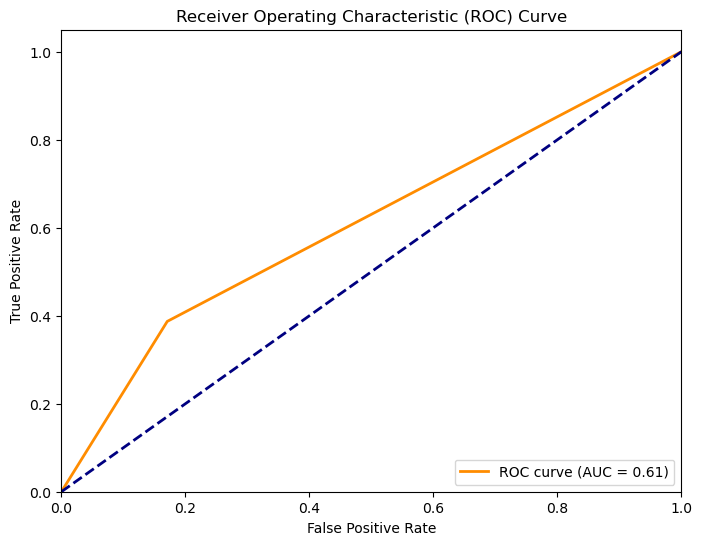

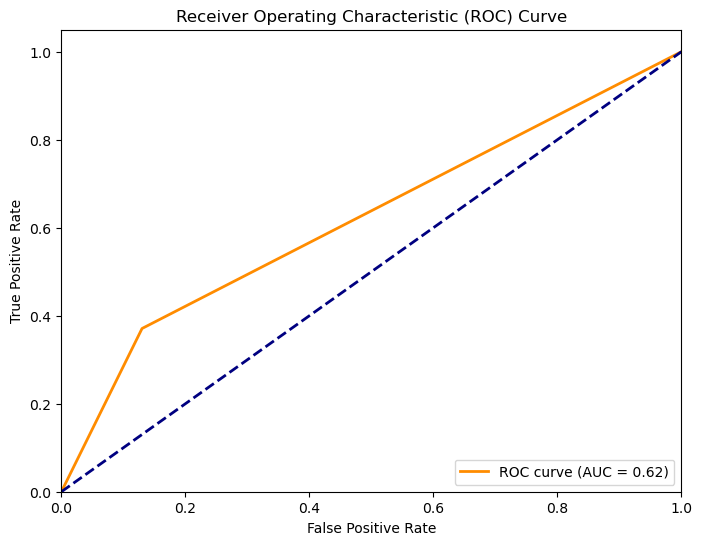

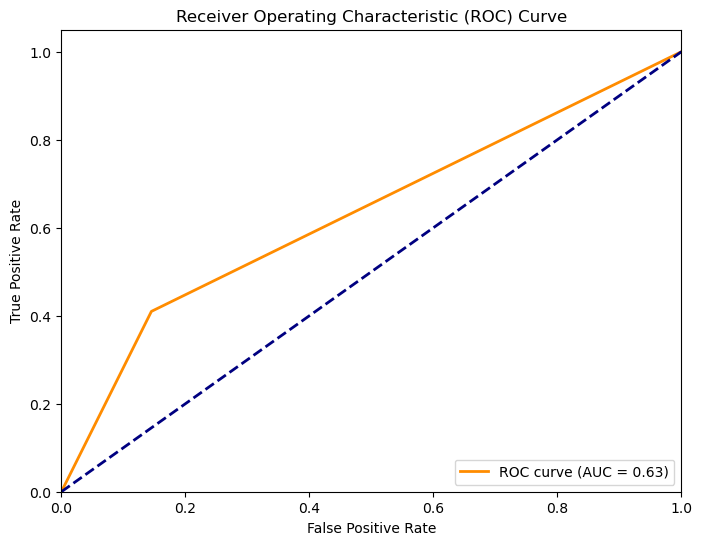

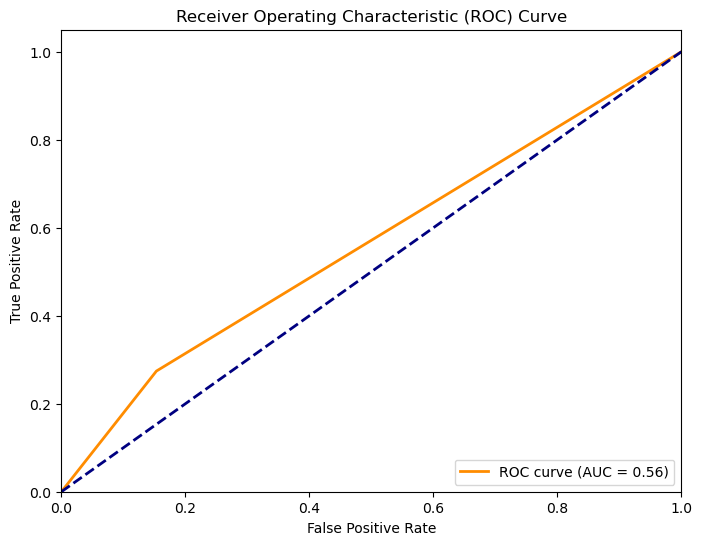

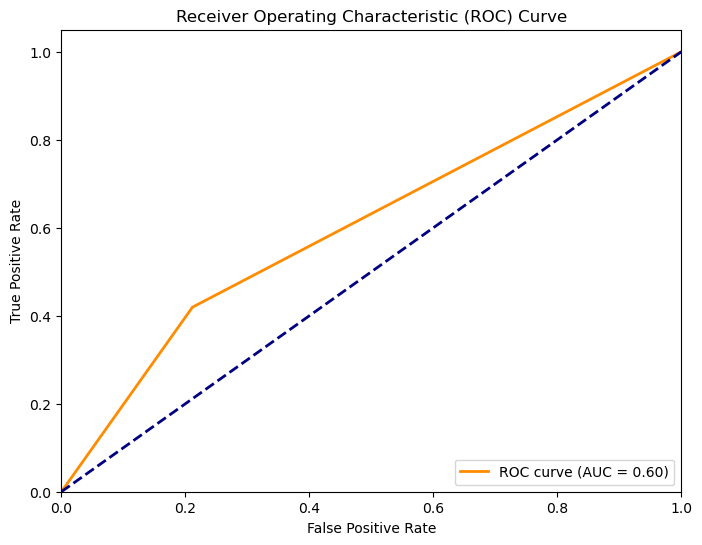

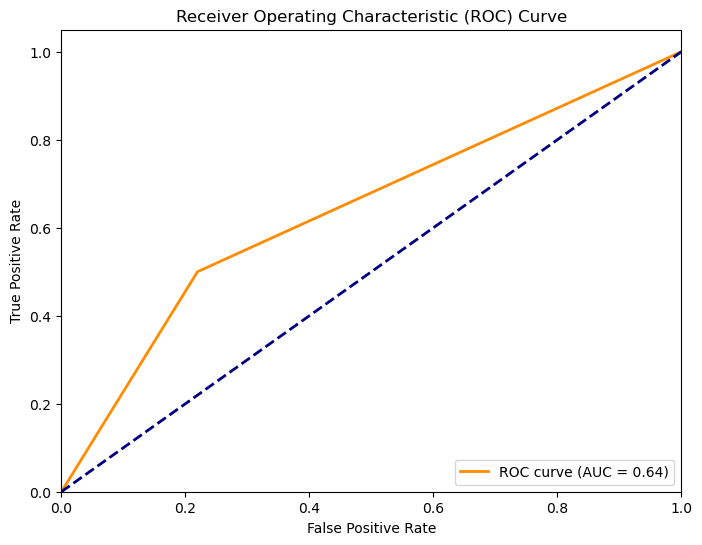

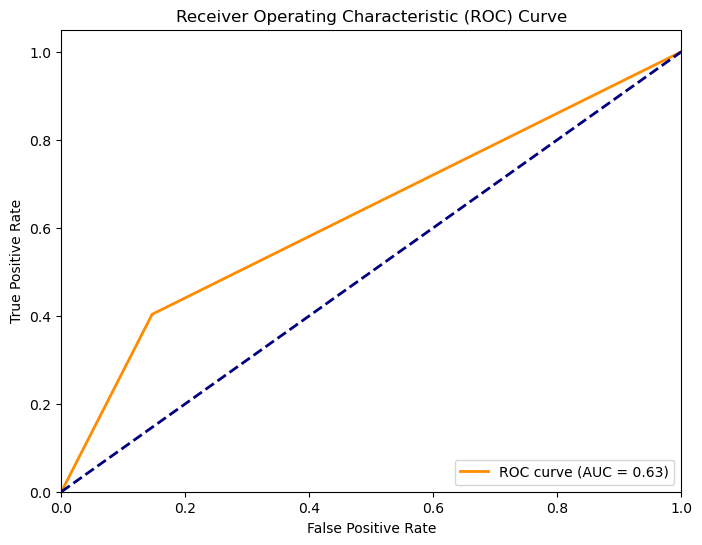

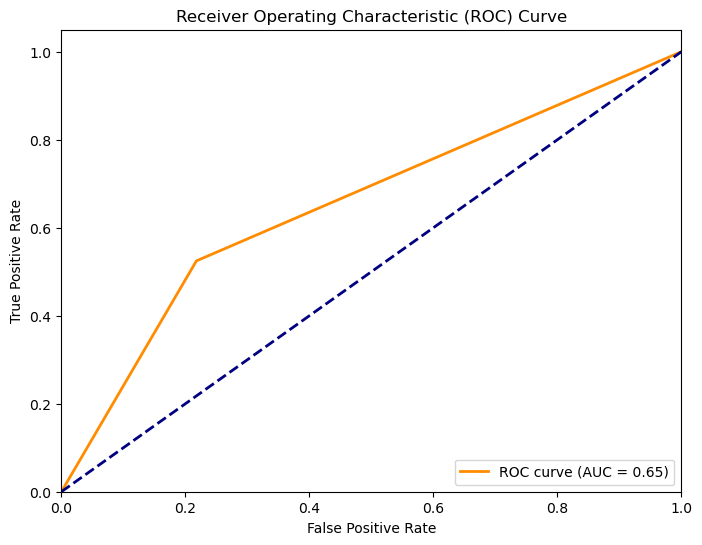

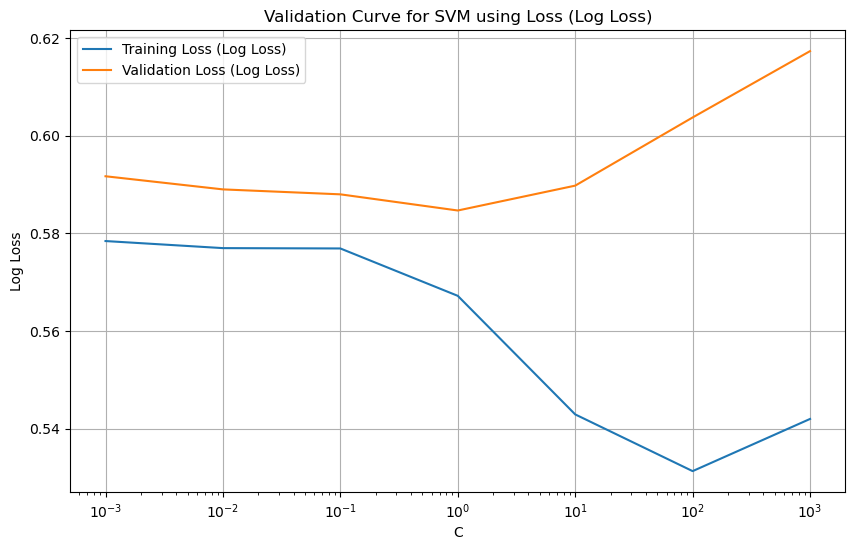

Average Accuracy: 0.6826728110599078


In [233]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import log_loss
from sklearn.metrics import accuracy_score
# Define the range of parameter values you want to test (e.g., C values)
param_range = np.logspace(-3, 3, 7)  # Range of C values to explore

# Initialize lists to store training and validation losses
train_losses = []
validation_losses = []
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)
accuracies = []
train_losses=[]
val_losses=[]
#X = cov_new[X]
#y = cov_new[y]
fold_accuracies = []   
    
for C_value in param_range:
    # Initialize lists to store losses for each fold
    fold_train_losses = []
    fold_validation_losses = []
    
    
    for train_idx, val_idx in kfold.split(X,y):
        X_train, X_val =X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # Train an SVM with the current C value
        svm = SVC(kernel='poly', C=C_value, random_state=0,probability=True)
        svm.fit(X_train, y_train)
        y_pred = svm.predict(X_val)
        accuracy = accuracy_score(y_val, y_pred)
        fold_accuracies.append(accuracy)
        
        fpr, tpr, thresholds = roc_curve(y_val, y_pred)
        roc_auc = auc(fpr, tpr)
        
        
        # Plot ROC curve
        plt.figure(figsize=(8, 6))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curve')
        plt.legend(loc="lower right")
        plt.show()
        
        # Calculate training and validation losses (log loss in this case)
        train_loss = log_loss(y_train, svm.predict_proba(X_train))
        validation_loss = log_loss(y_val, svm.predict_proba(X_val))
        
        # Append the losses for this fold
        fold_train_losses.append(train_loss)
        fold_validation_losses.append(validation_loss)
        accuracy = accuracy_score(y_val, y_pred)
        fold_accuracies.append(accuracy)
        
        
        
    # Calculate the mean loss across folds for this C value
    mean_train_loss = np.mean(fold_train_losses)
    mean_validation_loss = np.mean(fold_validation_losses)
    
    # Append the mean losses to the respective lists
    train_losses.append(mean_train_loss)
    validation_losses.append(mean_validation_loss)
    

    
plt.figure(figsize=(10, 6))
plt.semilogx(param_range, train_losses, label='Training Loss (Log Loss)')
plt.semilogx(param_range, validation_losses, label='Validation Loss (Log Loss)')
plt.xlabel('C')
plt.ylabel('Log Loss')
plt.title('Validation Curve for SVM using Loss (Log Loss)')
plt.legend()
plt.grid(True)
plt.show()


average_accuracy = np.mean(fold_accuracies)
print("Average Accuracy:", average_accuracy)






dceision tree


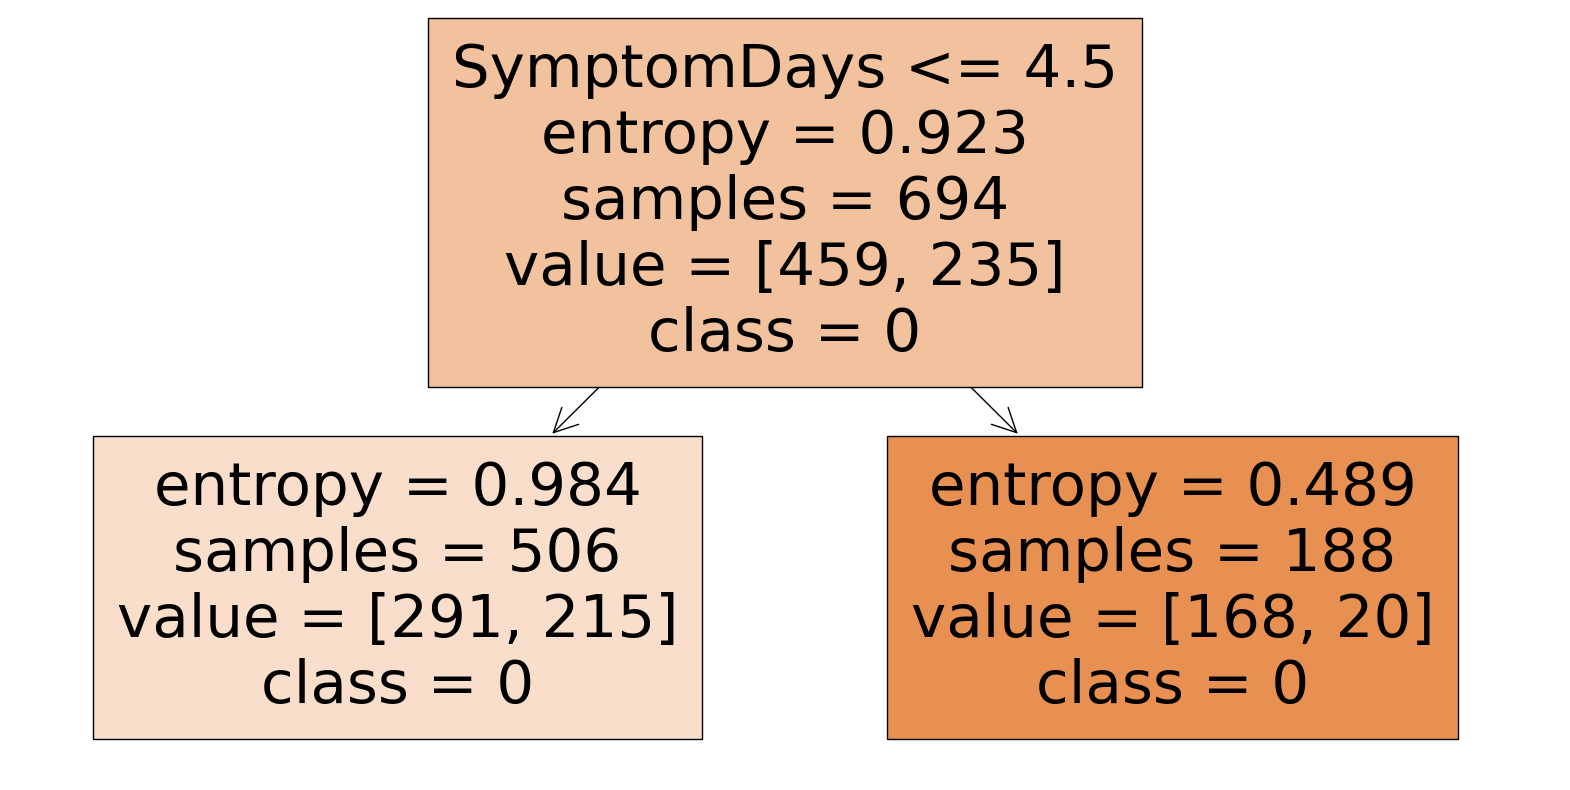

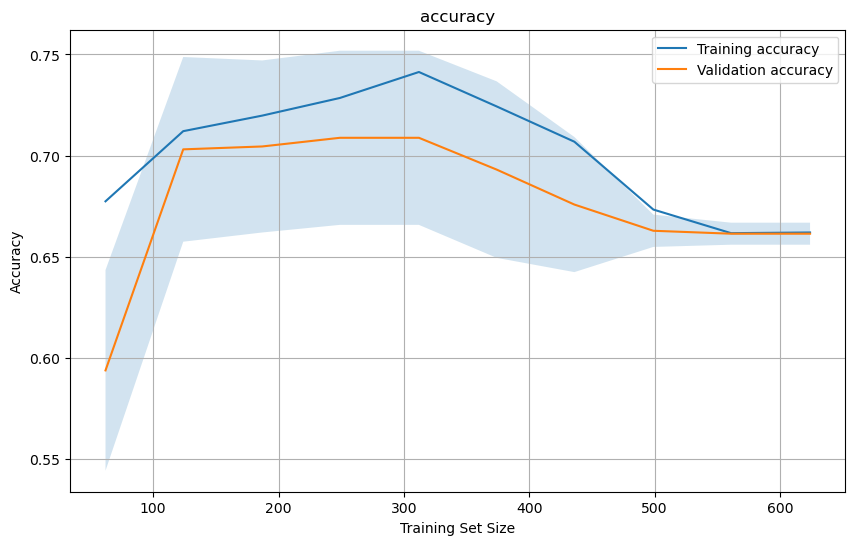

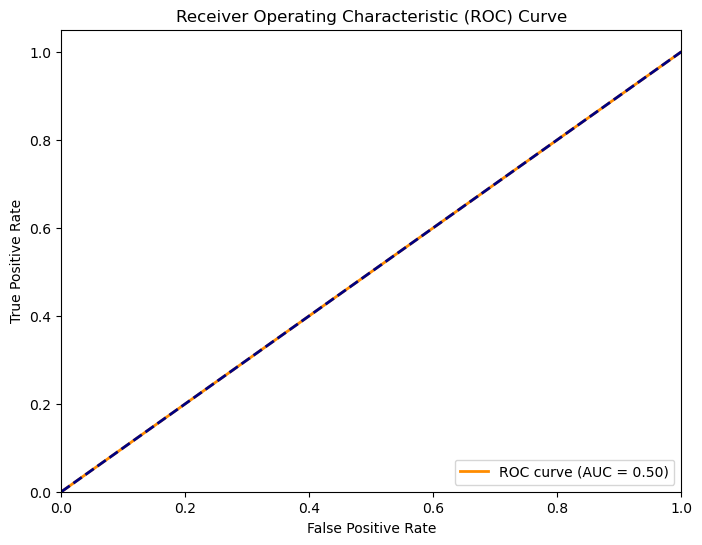

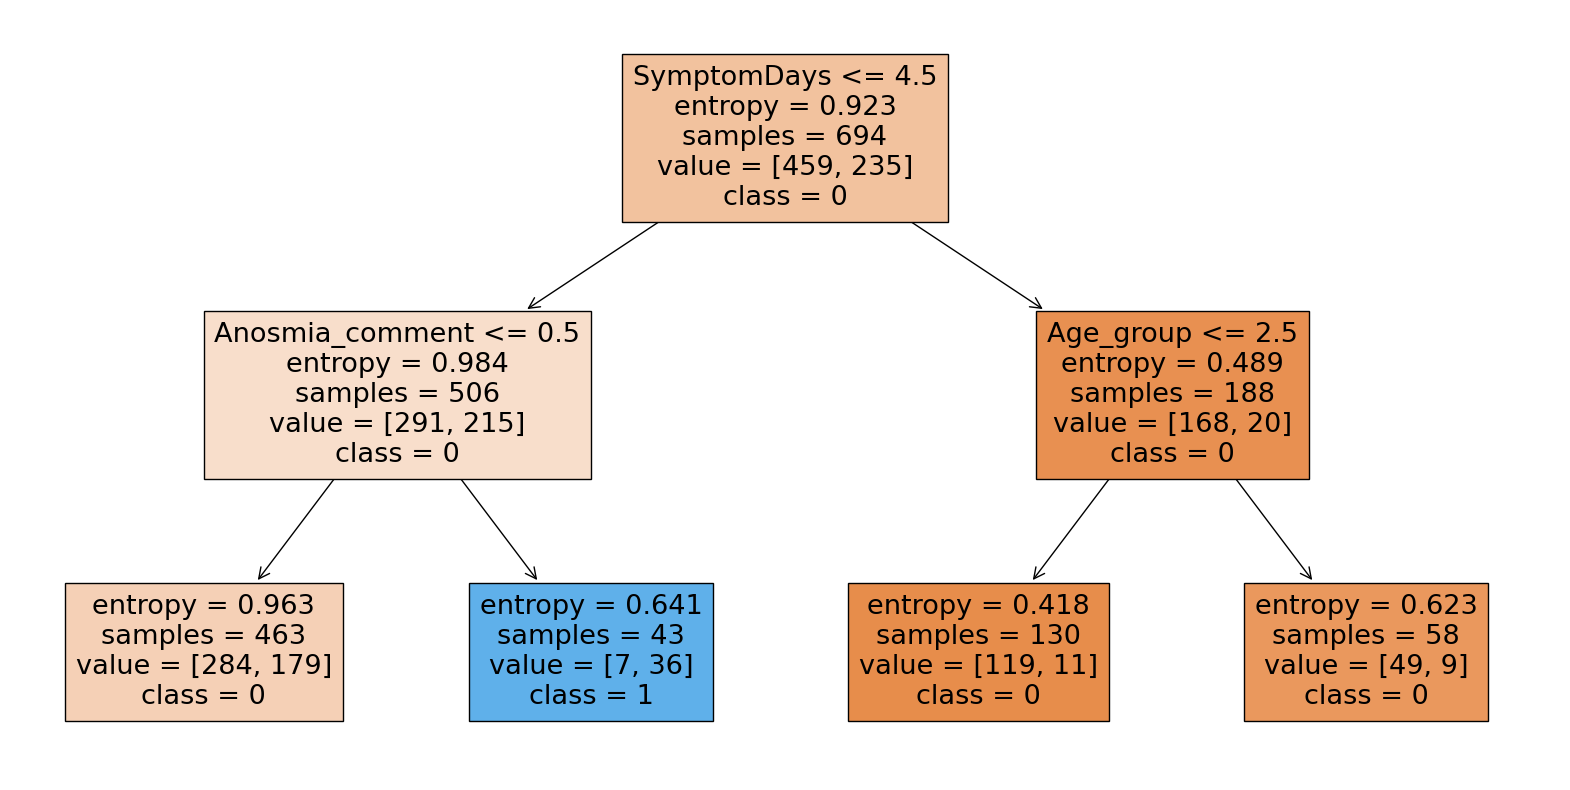

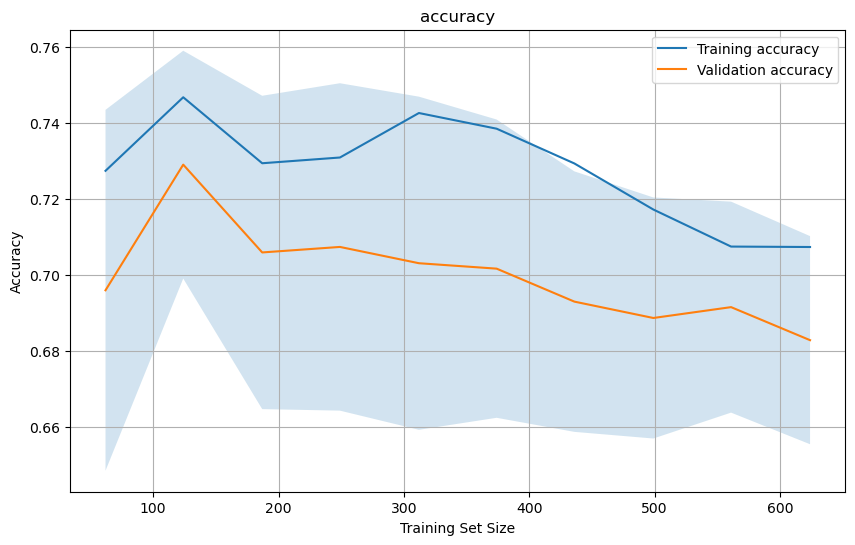

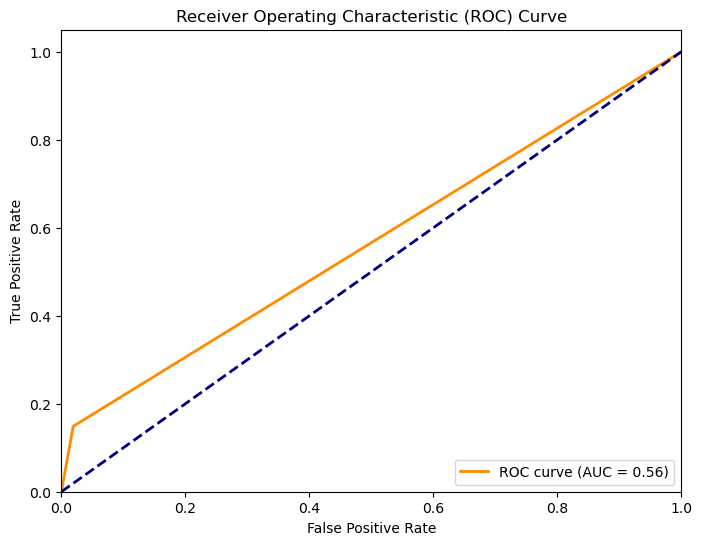

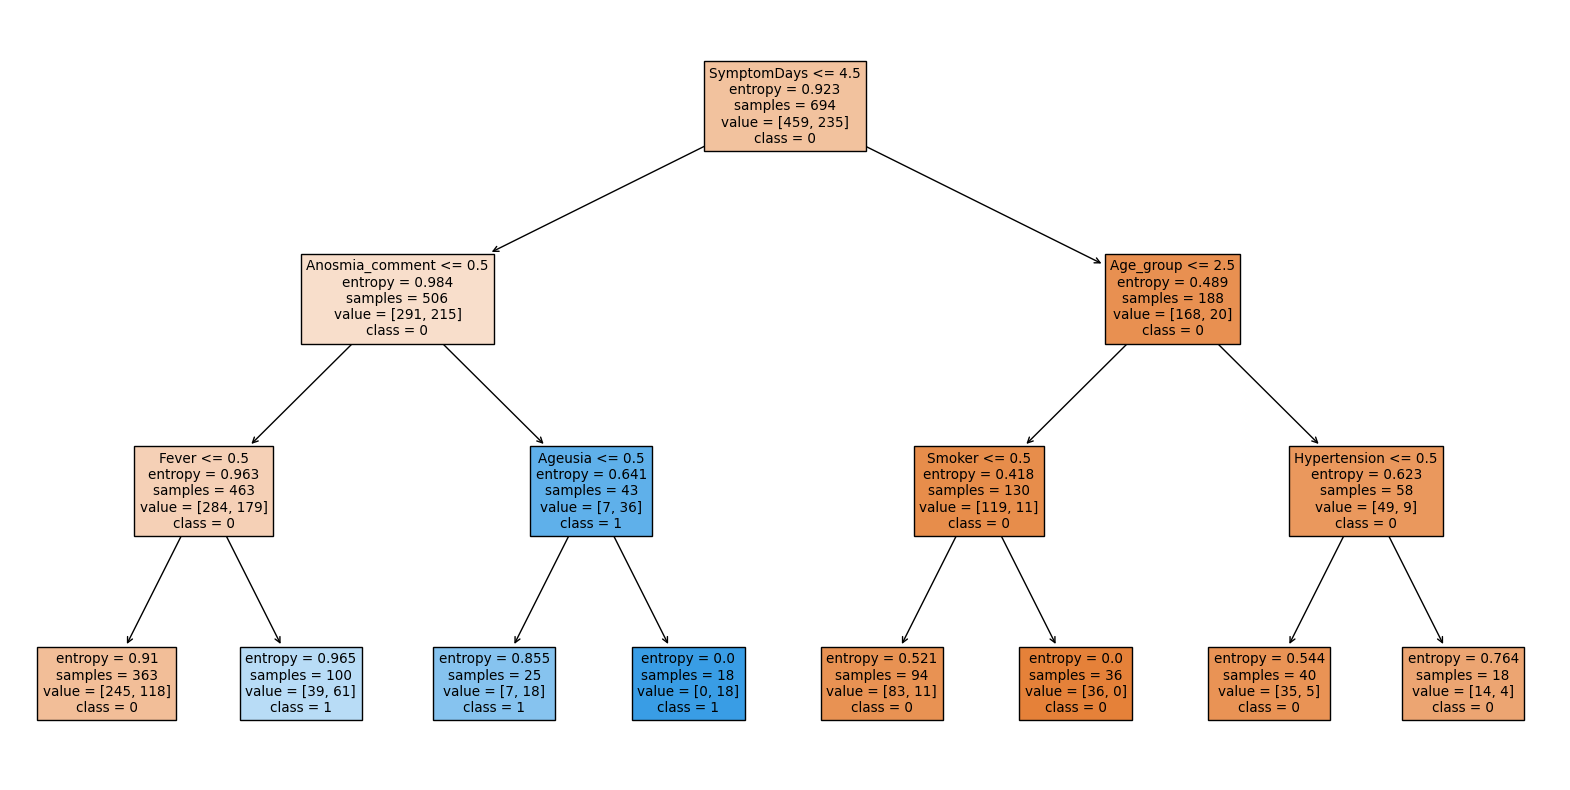

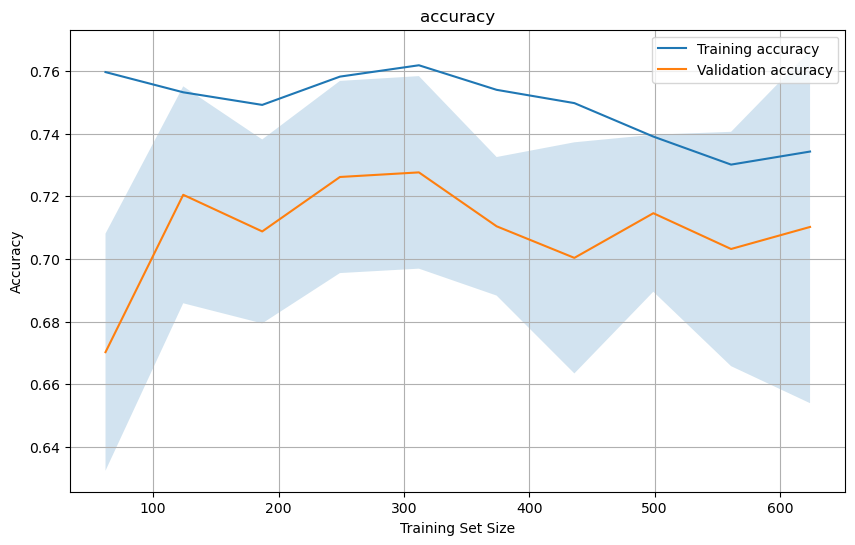

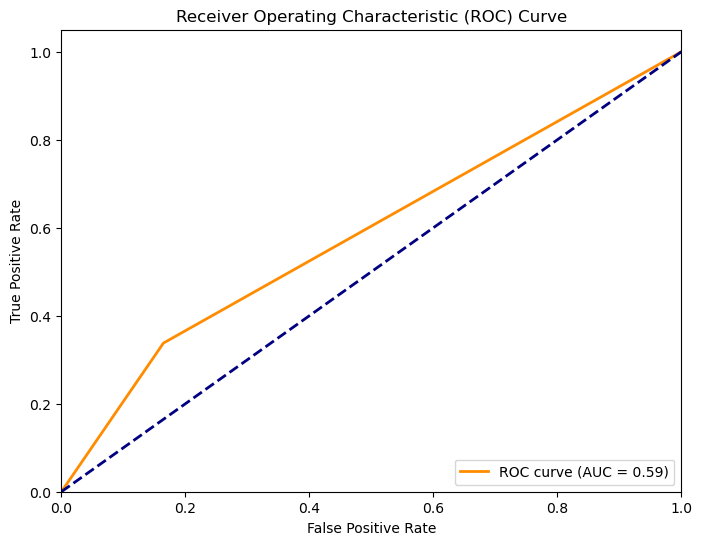

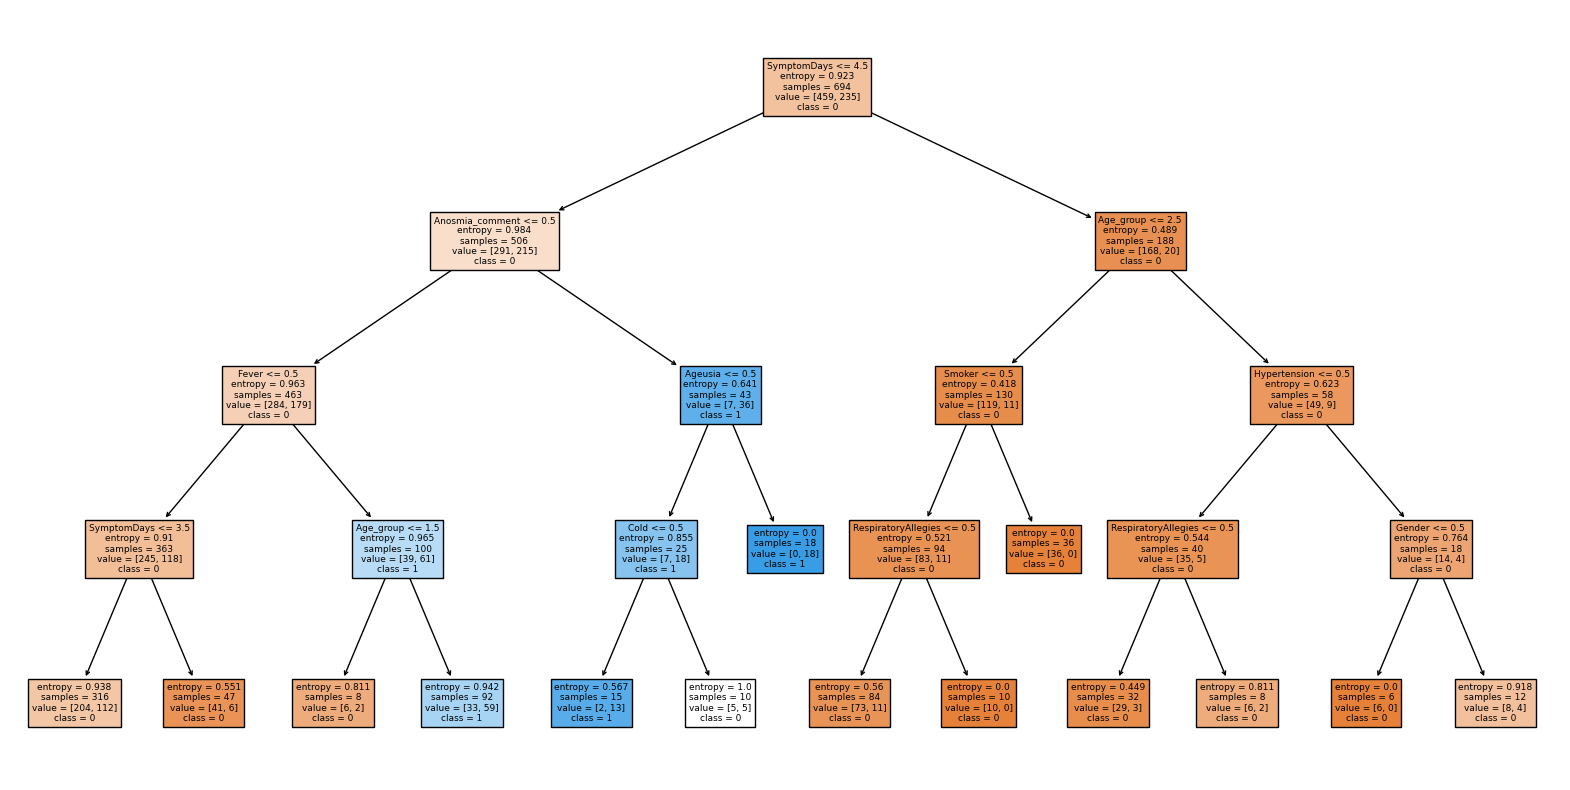

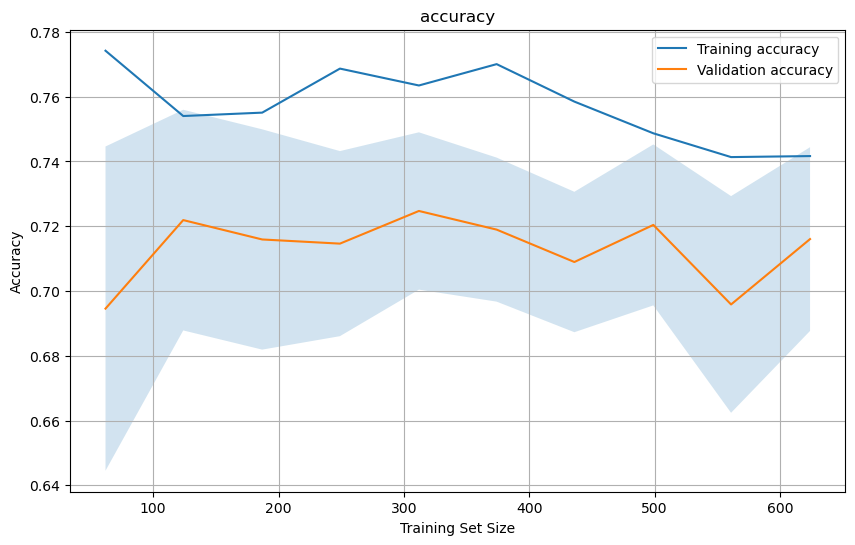

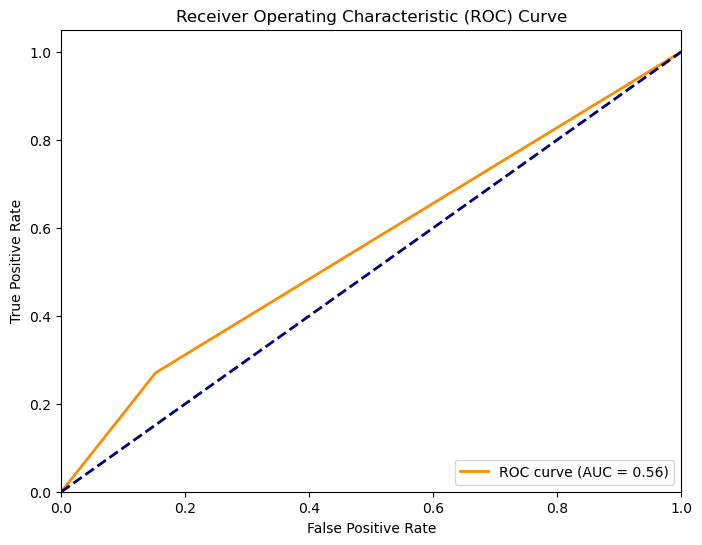

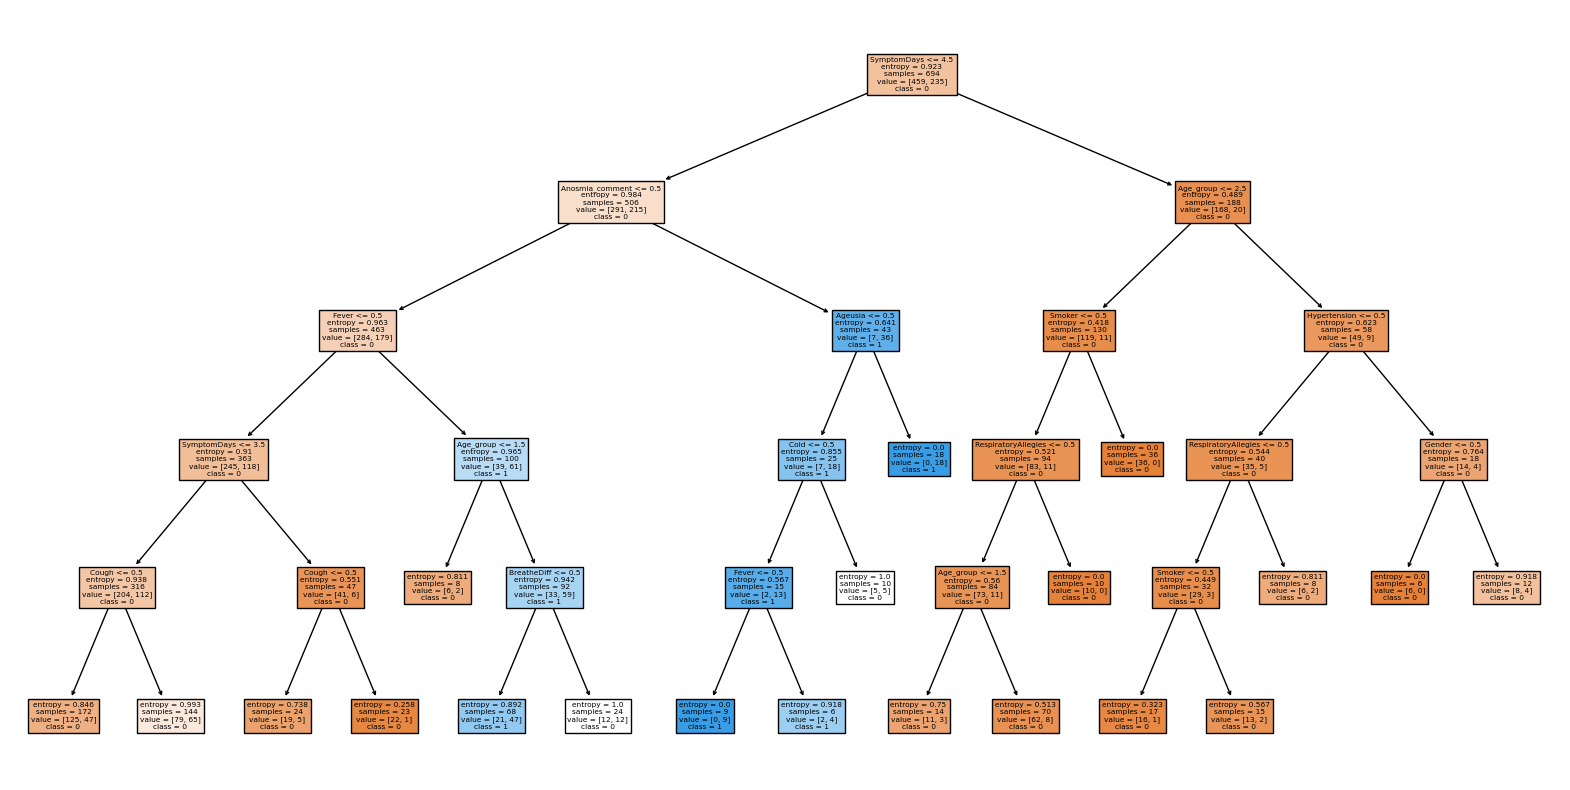

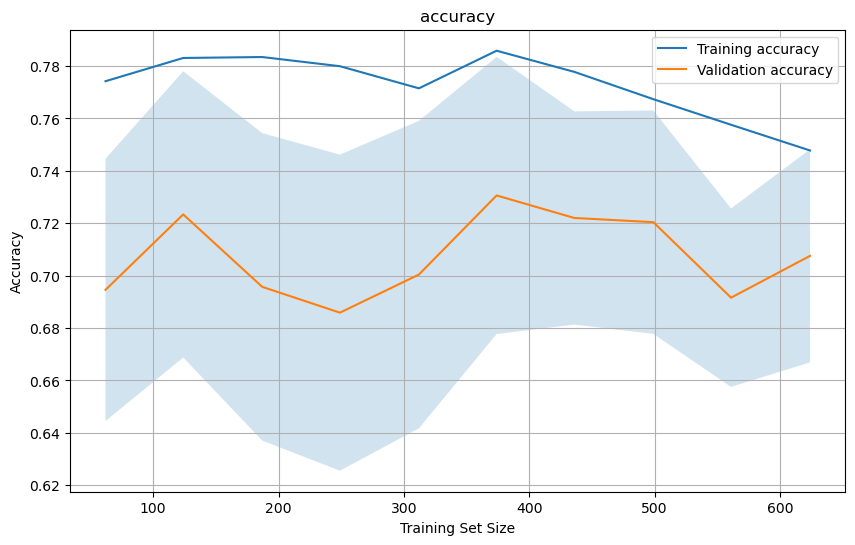

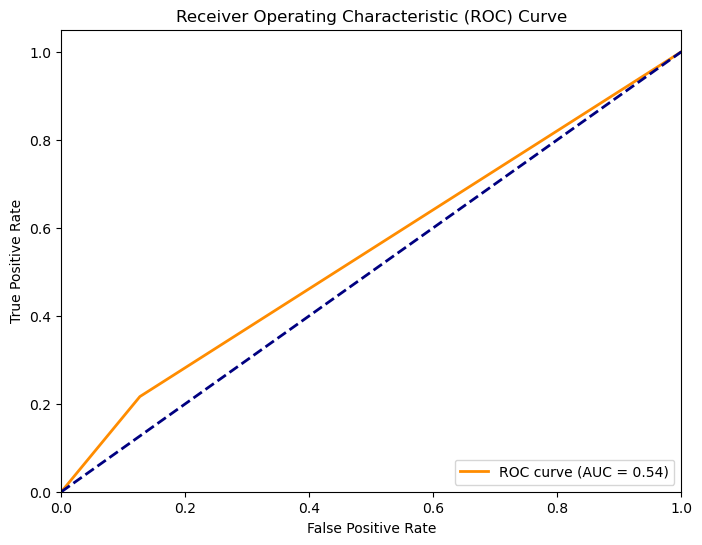

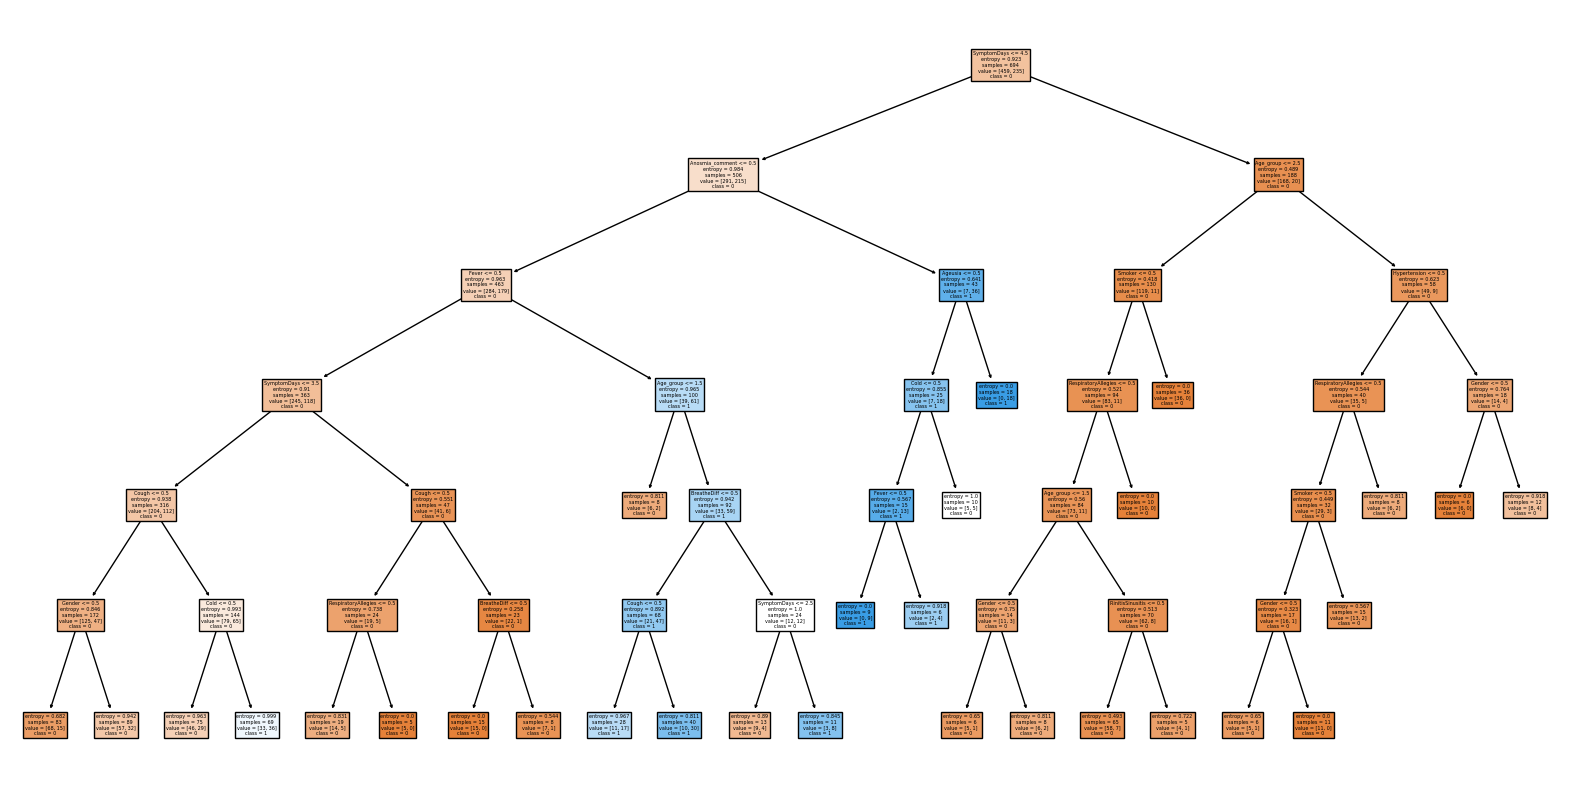

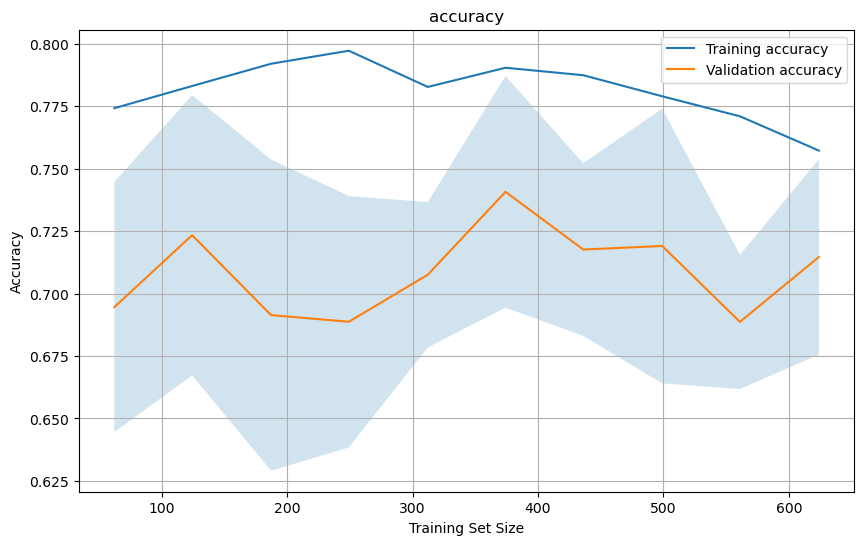

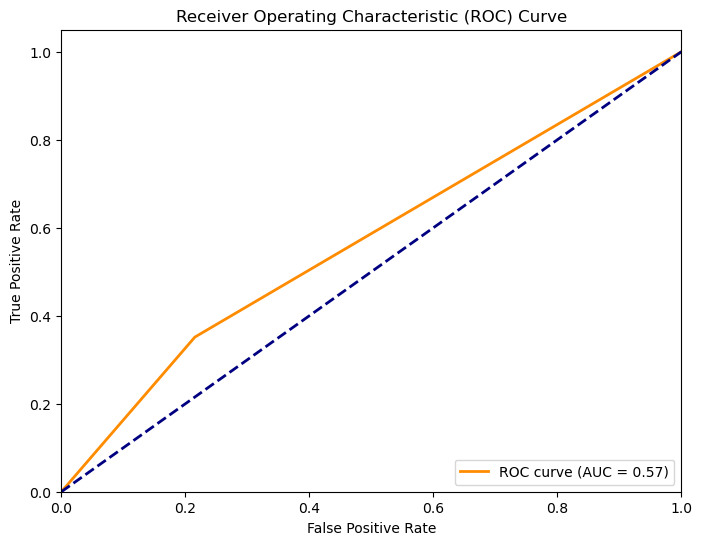

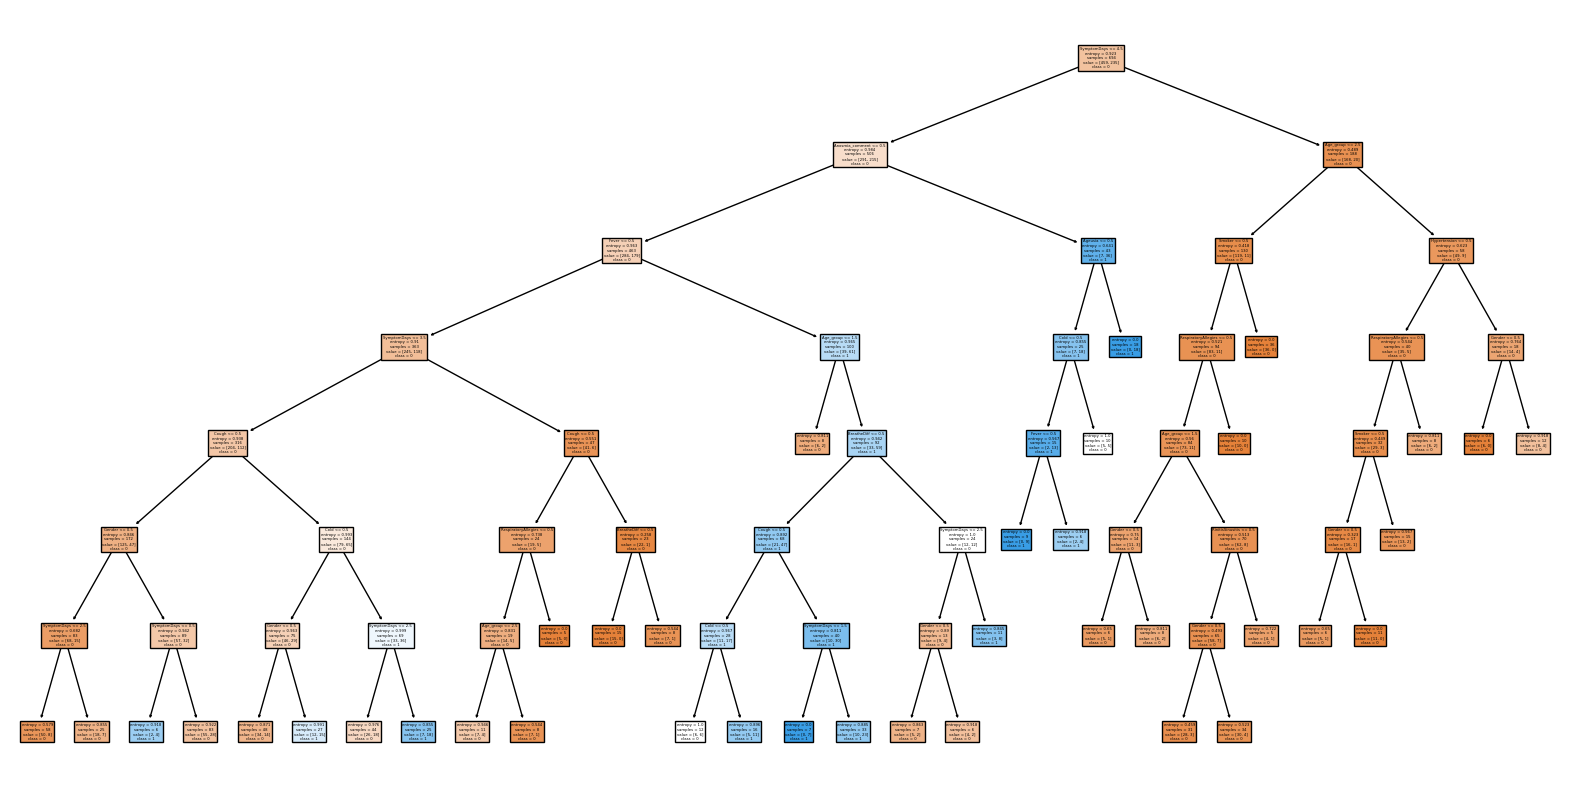

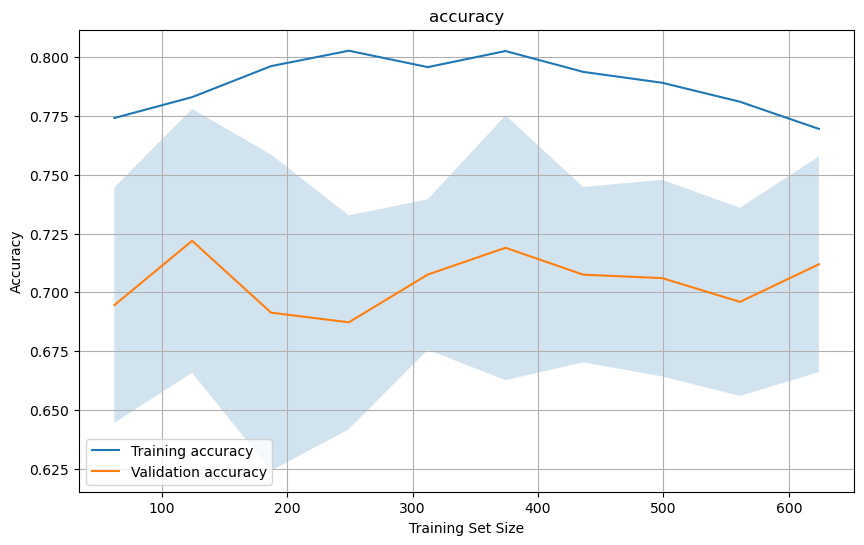

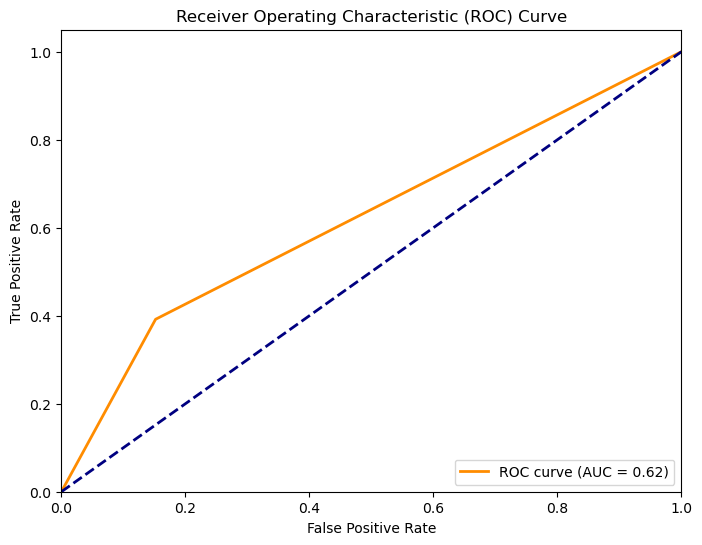

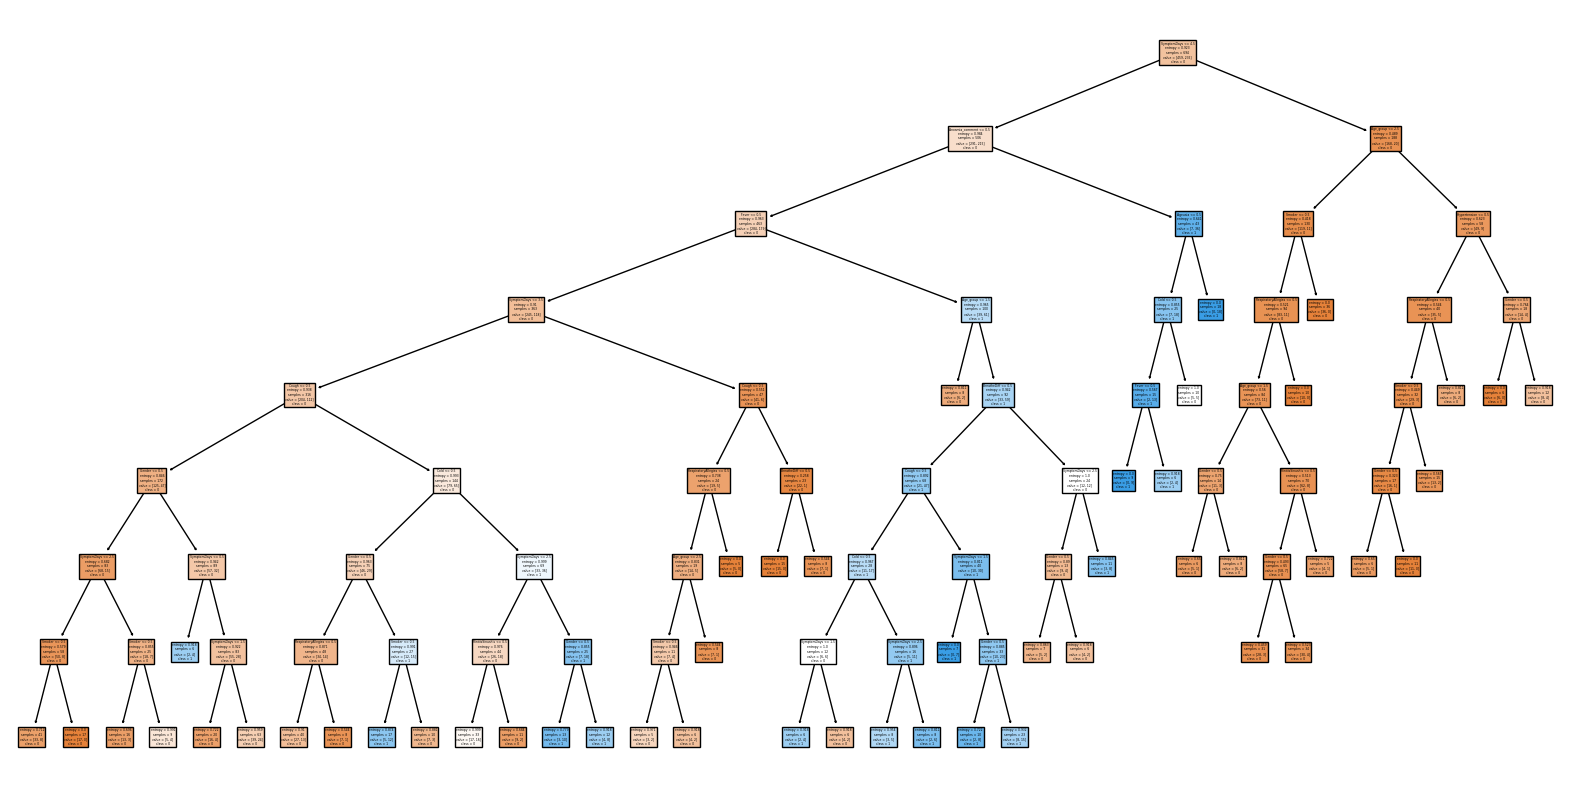

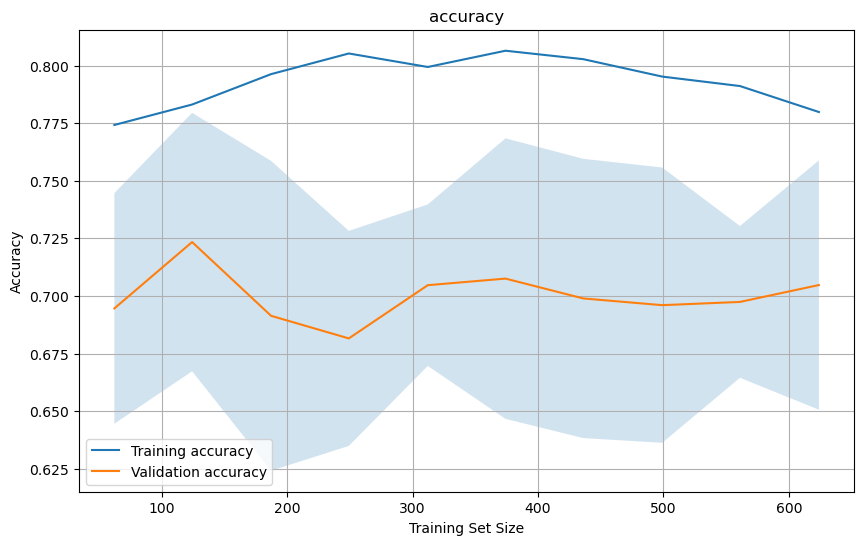

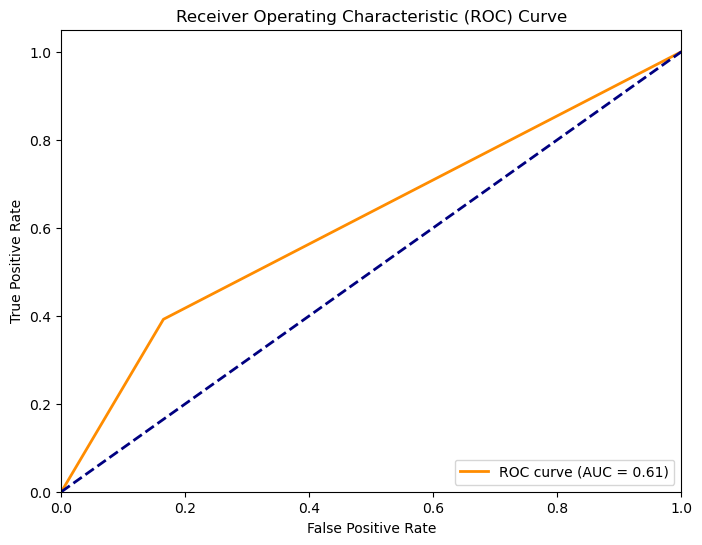

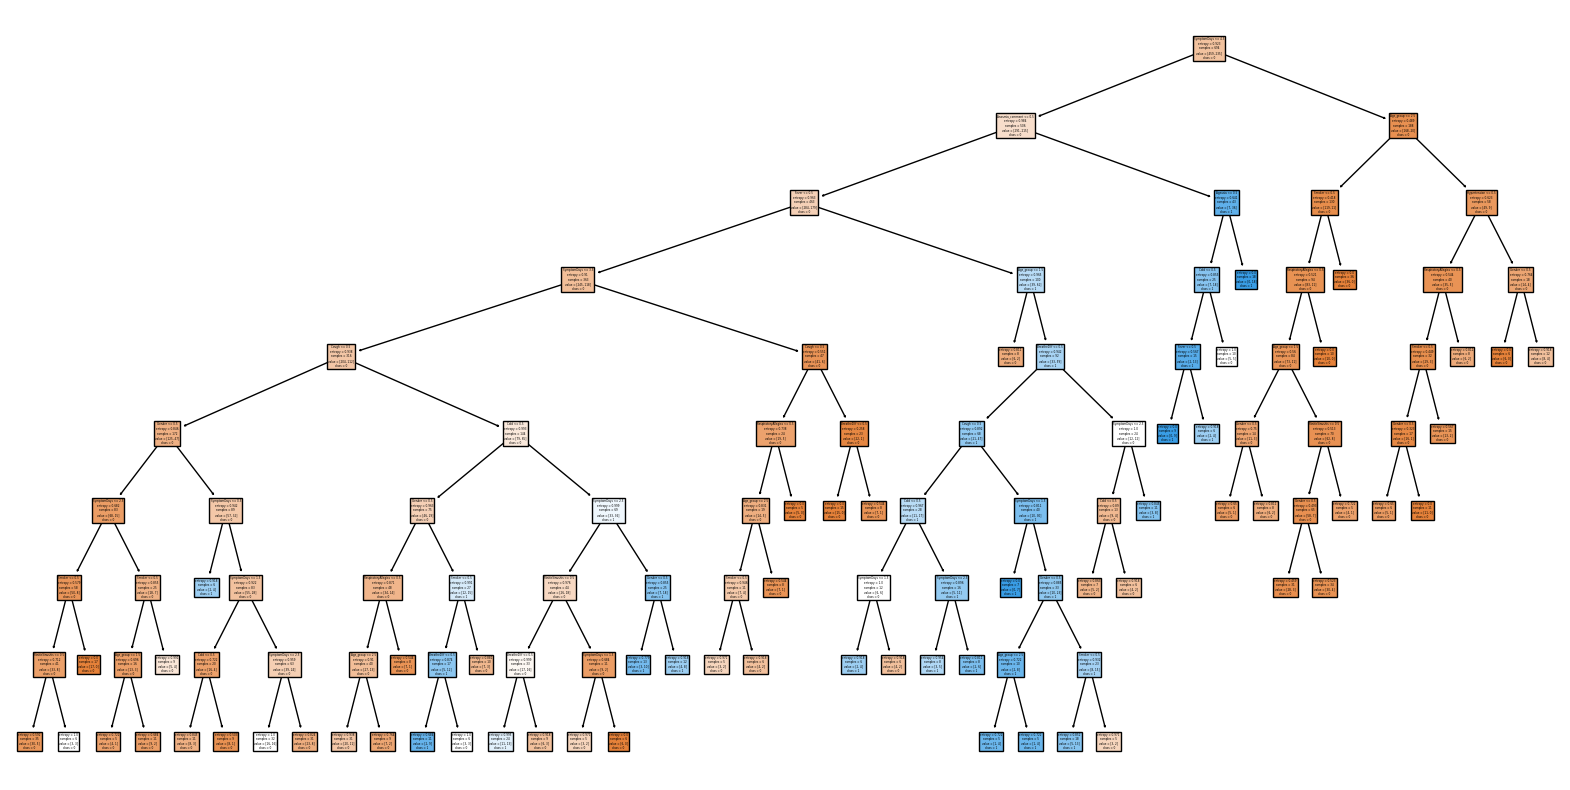

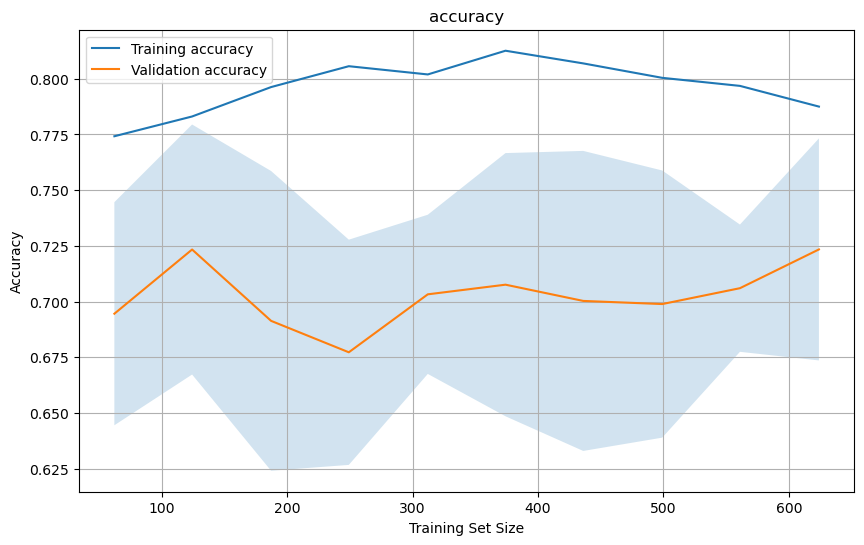

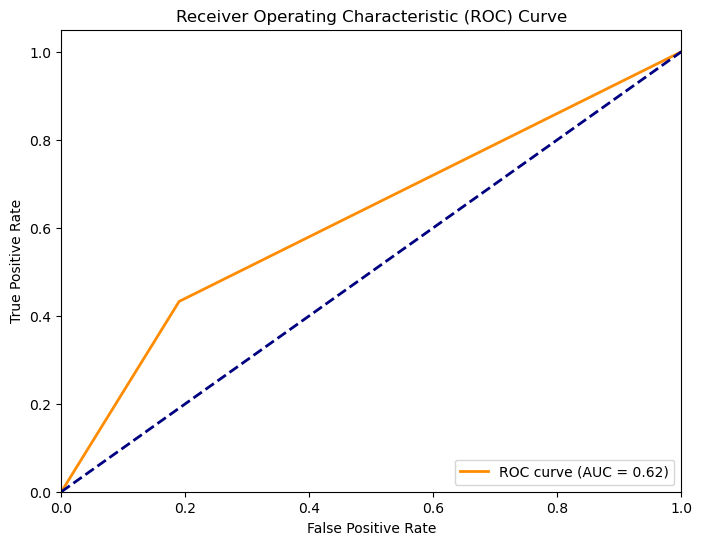

Average Accuracy: 0.7026107660455487


In [234]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.model_selection import learning_curve
from sklearn.metrics import confusion_matrix

X_train, X_test, y_train, y_test = train_test_split(cov_new[features], cov_new[target], test_size = 0.25)




for i in range(1,10):
    # Create a decision tree classifier
    clf = DecisionTreeClassifier(criterion="entropy", random_state=100, max_depth=i, min_samples_leaf=5)
    # Calculate learning curve
    train_sizes, train_scores, test_scores = learning_curve(
    clf, X_train, y_train, cv=10, train_sizes=np.linspace(0.1, 1.0, 10), scoring='accuracy', n_jobs=-1
)
    clf.fit(X_train, y_train)
    # Get the class names from the target variable
    class_names = y_train.unique().astype(str)
    # Plot the decision tree
    plt.figure(figsize=(20, 10))
    plot_tree(clf, filled=True, feature_names=X_train.columns, class_names=class_names)
    plt.show()
    # Calculate mean and standard deviation of scores
    mean_train_scores = np.mean(train_scores, axis=1)
    mean_test_scores = np.mean(test_scores, axis=1)
    std_test_scores = np.std(test_scores, axis=1)
    
    y_pred=clf.predict(X_test)
    # Plot learning curve
    plt.figure(figsize=(10, 6))
    plt.plot(train_sizes, mean_train_scores, label='Training accuracy')
    plt.plot(train_sizes, mean_test_scores, label='Validation accuracy')
    plt.fill_between(train_sizes, mean_test_scores - std_test_scores, mean_test_scores + std_test_scores, alpha=0.2)
    plt.xlabel('Training Set Size')
    plt.ylabel('Accuracy')
    plt.title('accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()
   
    #plot roc curve
    fpr, tpr, thresholds = roc_curve(y_test, y_pred)
    roc_auc = auc(fpr, tpr)
        
        
    # Plot ROC curve
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (AUC = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()
    
    
    
    
    



from sklearn.tree import DecisionTreeClassifier, plot_tree
print("Average Accuracy:", np.mean(mean_test_scores))

